# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 14 — Early Reversal Accumulation Pacing

**Research question:** once SuperbCommand identifies an `EARLY_REVERSAL`, should target exposure be established immediately or accumulated progressively over several weeks?

This notebook treats Early Reversal pacing as an **implementation / position-sizing problem**, not as a new signal-generation problem.

No oscillator, Bollinger Band, SuperTrend, Pullback, Profit-Taking, exit, portfolio-weighting, or asset-universe parameters are optimised here.

The goal is to determine whether staged accumulation:

- reduces path risk during failed or premature reversals;
- preserves enough participation in successful reversals;
- improves the shape of equity and crypto SuperbCommand returns;
- produces a broad and stable performance plateau rather than a single historically optimal step count.

## Predeclared pacing architectures

The following schedules are tested:

| Architecture | Target added per week | Time to 100% |
|---|---:|---:|
| `ER_IMMEDIATE` | 100% | 1 week |
| `ER_2_STEP` | 50% | 2 weeks |
| `ER_3_STEP` | 33.33%, 33.33%, 33.34% | 3 weeks |
| `ER_4_STEP` | 25% | 4 weeks |
| `ER_5_STEP` | 20% | 5 weeks |
| `ER_10_STEP` | 10% | 10 weeks |
| `ER_20_STEP` | 5% | 20 weeks |
| `ER_FRONTLOAD_50_25_25` | 50%, 25%, 25% | 3 weeks |

The 20-step architecture deliberately provides an extreme slow-accumulation endpoint.

## Key behavioural rule

Accumulation occurs only while the original SuperbCommand logic still permits the long position.

If the strategy exits before a staged schedule finishes, remaining scheduled additions are cancelled.

If Early Reversal ends because the strategy transitions into another **held** state before the schedule completes, the remaining staged additions may continue toward the normal 1.0 target unless the position subsequently exits. This isolates **entry pacing** rather than redefining downstream state logic.

Pullback and Profit-Taking behaviour is preserved exactly as in the upstream SuperbCommand variant.

## Primary assets of interest

Notebook 13B indicated the cleanest incremental SuperbCommand evidence in:

1. **Equities** — primary research focus.
2. **Crypto** — secondary sensitivity.

The notebook also saves all-market diagnostics where available, but no cross-asset step count is selected here.

## Anti-overfitting rule

The notebook does **not** choose the highest Sharpe step count automatically.

Instead it evaluates:

- performance monotonicity / plateau shape;
- drawdown trade-off;
- event-level success vs failure behaviour;
- subperiod stability;
- leave-one-year-out stability;
- moving-block bootstrap;
- cross-market consistency.

A staged architecture is only interesting if improvement is broad and interpretable.

## Final holdout

Research ends at **31 December 2025**.

The entire **2026 final holdout remains untouched**.


In [1]:
# ============================================================
# 14.1 — IMPORTS, DRIVE & CONFIGURATION
# ============================================================
from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = (
    Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy")
    if IN_COLAB
    else Path.cwd() / "Multi-Asset CTA Strategy"
)

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.json"
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 00 first.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

PATHS = {k: Path(v) for k, v in CFG["paths"].items()}
RESEARCH_END = pd.Timestamp(CFG["research_dates"]["research_end"])
HOLDOUT_START = pd.Timestamp(CFG["research_dates"]["holdout_start"])

if CFG["research_dates"]["unlock_holdout"]:
    raise RuntimeError("Notebook 14 cannot run with the 2026 holdout unlocked.")

print("Project root:", PROJECT_ROOT)
print("Research cutoff:", RESEARCH_END.date())
print("2026 holdout: LOCKED")


Mounted at /content/drive
Project root: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Research cutoff: 2025-12-31
2026 holdout: LOCKED


## 14.2 Load the actual Notebook 02 SuperbCommand research panel

Notebook 14 now identifies the upstream file by its **schema**, rather than by a guessed filename.

The authoritative Notebook 02 panel contains the original signal-engine fields, including:

- `close`
- `position_held`
- `standby_active`
- `early_reversal_active`
- `pullback_active`
- `profit_taking_active`
- `start_early_reversal`

Weekly market returns are reconstructed directly from the same panel's `close` series. This guarantees exact signal/return date alignment and removes a second fragile upstream-file dependency.


In [2]:
# ============================================================
# 14.2 — DISCOVER & LOAD NOTEBOOK 02 SIGNAL PANEL
# ============================================================

def find_candidate_files(root, patterns):
    found = []
    if root.exists():
        for pattern in patterns:
            found.extend(root.rglob(pattern))
    return list(dict.fromkeys(found))


# ------------------------------------------------------------
# 1) Discover candidate parquet files
# ------------------------------------------------------------
candidates = find_candidate_files(
    PATHS["data_processed"],
    [
        "*signal*.parquet",
        "*superbcommand*.parquet",
        "*state*.parquet",
        "*.parquet",
    ],
)

if not candidates:
    raise FileNotFoundError(
        f"No parquet files found under {PATHS['data_processed']}"
    )


# ------------------------------------------------------------
# 2) Score candidates by the distinctive Notebook 02 schema
# ------------------------------------------------------------
#
# IMPORTANT:
# We do NOT require a perfect schema match here.
# Earlier notebooks evolved and some saved panels omit a small number
# of convenience fields. The correct signal panel is instead identified
# by a combination of:
#
#   • core price fields
#   • SuperbCommand indicator fields
#   • event / regime fields
#   • row count / column richness
#
# Cell 14.3 performs the strict downstream field validation.
# ------------------------------------------------------------

CORE_FIELDS = {
    "open",
    "high",
    "low",
    "close",
}

SIGNAL_FIELDS = {
    "oscillator",
    "signal_line",
    "fast_ma",
    "slow_ma",
}

REGIME_FIELDS = {
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "position_held",
    "start_early_reversal",
    "standby_active",
    "zone_mode",
}

IDENTITY_FIELDS = {
    "ticker",
    "date",
}

schema_rows = []

for p in candidates:
    try:
        df = pd.read_parquet(p)
        cols = {str(c) for c in df.columns}

        core_hits = len(CORE_FIELDS.intersection(cols))
        signal_hits = len(SIGNAL_FIELDS.intersection(cols))
        regime_hits = len(REGIME_FIELDS.intersection(cols))
        identity_hits = len(IDENTITY_FIELDS.intersection(cols))

        score = (
            core_hits * 2
            + signal_hits * 3
            + regime_hits * 5
            + identity_hits * 5
        )

        # Rich Notebook 02 panels are wide. Reward that modestly.
        if len(df.columns) >= 40:
            score += 10

        # The research panel should also be long enough to cover the universe.
        if len(df) >= 5000:
            score += 5

        schema_rows.append({
            "path": str(p),
            "rows": len(df),
            "columns": len(df.columns),
            "score": score,
            "identity_hits": identity_hits,
            "core_hits": core_hits,
            "signal_hits": signal_hits,
            "regime_hits": regime_hits,
            "column_names": list(map(str, df.columns)),
        })

    except Exception as e:
        schema_rows.append({
            "path": str(p),
            "rows": np.nan,
            "columns": np.nan,
            "score": -1,
            "identity_hits": 0,
            "core_hits": 0,
            "signal_hits": 0,
            "regime_hits": 0,
            "column_names": [],
            "error": str(e),
        })


candidate_schema = pd.DataFrame(schema_rows).sort_values(
    ["score", "columns", "rows"],
    ascending=[False, False, False],
)

display(
    candidate_schema[
        [
            "path",
            "rows",
            "columns",
            "score",
            "identity_hits",
            "core_hits",
            "signal_hits",
            "regime_hits",
            "column_names",
        ]
    ].head(15)
)


# ------------------------------------------------------------
# 3) Select the strongest Notebook 02-like panel
# ------------------------------------------------------------

best = candidate_schema.iloc[0]

# Minimum safeguard:
# must have OHLC / close information, several signal-engine fields,
# and several regime/event fields.
if (
    best["core_hits"] < 1
    or best["signal_hits"] < 2
    or best["regime_hits"] < 3
):
    raise FileNotFoundError(
        "Notebook 14 could not identify a sufficiently convincing "
        "Notebook 02 SuperbCommand signal panel."
    )

SIGNAL_PATH = Path(best["path"])
signals = pd.read_parquet(SIGNAL_PATH)


# ------------------------------------------------------------
# 4) Report exactly what was selected
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("NOTEBOOK 14 — UPSTREAM ARTIFACT")
print("=" * 78)

print("\nSelected signal panel:")
print(SIGNAL_PATH)

print("\nShape:", signals.shape)

print("\nColumns:")
print(list(signals.columns))

selected_cols = set(map(str, signals.columns))

print("\nExpected field availability:")
for field in [
    "ticker",
    "date",
    "close",
    "position_held",
    "standby_active",
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "start_early_reversal",
]:
    print(f"{field:<28} {field in selected_cols}")

print(
    "\nWeekly market returns will be reconstructed directly from the "
    "selected panel's close series once Cell 14.3 has normalised the "
    "ticker/date structure."
)


,path,rows,columns,score,identity_hits,core_hits,signal_hits,regime_hits,column_names
0,/content/drive/MyDrive/Colab Notebooks/SuperbC...,11370,55,70,0,4,4,7,"[open, high, low, close, smoothed_price, fast_..."
4,/content/drive/MyDrive/Colab Notebooks/SuperbC...,11370,24,15,2,0,0,0,"[date, original_close, original_return, origin..."
3,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,154,10,0,0,0,0,"[('BTC-USD', 'CORE', 'long_cash'), ('BTC-USD',..."
5,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,44,10,0,0,0,0,"[('hier_equal_weight', 'BTC-USD'), ('hier_equa..."
1,/content/drive/MyDrive/Colab Notebooks/SuperbC...,6567,11,5,0,0,0,0,"[SPY, EFA, EEM, SHY, IEF, TLT, TIP, GLD, DBC, ..."
2,/content/drive/MyDrive/Colab Notebooks/SuperbC...,6567,11,5,0,0,0,0,"[SPY, EFA, EEM, SHY, IEF, TLT, TIP, GLD, DBC, ..."
12,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,25,0,0,0,0,0,"[('commodities', 'SC_CORE'), ('commodities', '..."
6,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,12,0,0,0,0,0,"[('CORE', 'hier_equal_weight'), ('CORE', 'hier..."
8,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,10,0,0,0,0,0,"[('SUPERBCOMMAND_CORE', 'hier_equal_weight'), ..."
16,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1016,7,0,0,0,0,0,"[DUAL_RECONSTRUCTED, EQUITIES_SC__FROZEN_WEIGH..."



NOTEBOOK 14 — UPSTREAM ARTIFACT

Selected signal panel:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/superbcommand_weekly_signal_panel.parquet

Shape: (11370, 55)

Columns:
['open', 'high', 'low', 'close', 'smoothed_price', 'fast_ma', 'slow_ma', 'oscillator', 'signal_line', 'spread', 'oscillator_slope', 'signal_slope', 'osc_rising', 'osc_falling', 'signal_rising', 'signal_falling', 'osc_turns_red', 'spread_std', 'upper_bb', 'lower_bb', 'atr', 'assigned_centroid', 'vol_cluster', 'supertrend', 'supertrend_dir', 'supertrend_bullish', 'supertrend_bearish', 'signal_cross_above_zero', 'osc_cross_above_signal', 'osc_cross_above_lower_bb', 'osc_cross_below_upper_bb', 'start_early_reversal', 'start_pullback', 'end_early_reversal', 'end_pullback', 'start_profit_taking', 'end_profit_taking', 'position_entry_event', 'position_exit_event', 'standby_anchor_event', 'position_held', 'standby_active', 'early_reversal_active', 'pullback_active', 'profit_t

## 14.3 Reconstruct the six research states from Notebook 02's authoritative flags

The Notebook 02 output does **not** store the later six-state diagnostic label as a single categorical column.

Its `zone_mode` field is numeric/internal, so Notebook 14 does not use it as a state label.

Instead the research states are reconstructed from the original boolean engine outputs:

- `standby_active` → `STANDBY`
- `early_reversal_active` → `EARLY_REVERSAL`
- `pullback_active` → `PULLBACK`
- `profit_taking_active` → `PROFIT_TAKING`
- `position_held=True` with none of the above → `HELD_NEUTRAL`
- otherwise → `OUT`

This matches the conceptual state taxonomy used in the later diagnostic notebooks while preserving Notebook 02 as the source of truth.


In [3]:
# ============================================================
# 14.3 — NORMALISE NOTEBOOK 02 SIGNAL PANEL
# ============================================================

sig = signals.copy()

# ------------------------------------------------------------
# Flatten any named index levels
# ------------------------------------------------------------
if isinstance(sig.index, pd.MultiIndex):
    sig = sig.reset_index()
elif sig.index.name is not None:
    sig = sig.reset_index()

sig.columns = [str(c) for c in sig.columns]


# ------------------------------------------------------------
# Flexible identity-field normalisation
# ------------------------------------------------------------
def detect_col(frame, candidates):
    lookup = {str(c).lower(): str(c) for c in frame.columns}
    for c in candidates:
        if c.lower() in lookup:
            return lookup[c.lower()]
    return None


ticker_src = detect_col(
    sig,
    ["ticker", "symbol", "market", "security"],
)

date_src = detect_col(
    sig,
    ["date", "timestamp", "datetime"],
)

if ticker_src is None or date_src is None:
    raise KeyError(
        "Could not identify ticker/date fields in the selected Notebook 02 "
        f"panel. Available columns: {list(sig.columns)}"
    )

if ticker_src != "ticker":
    sig = sig.rename(columns={ticker_src: "ticker"})

if date_src != "date":
    sig = sig.rename(columns={date_src: "date"})


# ------------------------------------------------------------
# Strict downstream schema check
# ------------------------------------------------------------
required = [
    "ticker",
    "date",
    "close",
    "position_held",
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "start_early_reversal",
]

missing = [c for c in required if c not in sig.columns]

if missing:
    raise KeyError(
        "The selected panel looks like Notebook 02, but Notebook 14 still "
        f"needs these fields: {missing}. "
        f"Available columns: {list(sig.columns)}"
    )

# standby_active is helpful but not strictly required. If absent,
# reconstruct it conservatively from explicit standby/event information.
if "standby_active" not in sig.columns:
    if "standby_bars_elapsed" in sig.columns:
        sig["standby_active"] = (
            pd.to_numeric(sig["standby_bars_elapsed"], errors="coerce")
            .fillna(0)
            .gt(0)
        )
    else:
        sig["standby_active"] = False

TICKER_COL = "ticker"
DATE_COL = "date"

sig[DATE_COL] = pd.to_datetime(sig[DATE_COL])
sig = sig[sig[DATE_COL] <= RESEARCH_END].copy()

if sig[DATE_COL].max() >= HOLDOUT_START:
    raise RuntimeError("2026 contamination detected in signal panel.")


# ------------------------------------------------------------
# Boolean normalisation
# ------------------------------------------------------------
bool_cols = [
    "position_held",
    "standby_active",
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "start_early_reversal",
]

optional_bool_cols = [
    "end_early_reversal",
    "start_pullback",
    "end_pullback",
    "start_profit_taking",
    "end_profit_taking",
    "position_entry_event",
    "position_exit_event",
    "start_accumulating",
    "end_accumulating",
]

for c in bool_cols + [x for x in optional_bool_cols if x in sig.columns]:
    sig[c] = sig[c].fillna(False).astype(bool)


# ------------------------------------------------------------
# Reconstruct the six research states from the authoritative flags
# ------------------------------------------------------------
#
# IMPORTANT:
# `zone_mode` in Notebook 02 is numeric/internal and is NOT the six-state
# categorical field used in the later diagnostic notebooks.
#
# State priority:
#   STANDBY
#   EARLY_REVERSAL
#   PULLBACK
#   PROFIT_TAKING
#   HELD_NEUTRAL
#   OUT
#
# This uses the actual active-state booleans rather than reverse-engineering
# state labels from the numeric zone_mode field.
# ------------------------------------------------------------
conditions = [
    sig["standby_active"],
    sig["early_reversal_active"],
    sig["pullback_active"],
    sig["profit_taking_active"],
    (
        sig["position_held"]
        & ~sig["standby_active"]
        & ~sig["early_reversal_active"]
        & ~sig["pullback_active"]
        & ~sig["profit_taking_active"]
    ),
]

choices = [
    "STANDBY",
    "EARLY_REVERSAL",
    "PULLBACK",
    "PROFIT_TAKING",
    "HELD_NEUTRAL",
]

sig["state"] = np.select(
    conditions,
    choices,
    default="OUT",
)

STATE_COL = "state"


# ------------------------------------------------------------
# Asset-class mapping
# ------------------------------------------------------------
fallback_map = {
    "SPY": "equities",
    "EFA": "equities",
    "EEM": "equities",
    "BTC-USD": "crypto",
    "DBC": "commodities",
    "GLD": "commodities",
    "UUP": "fx",
    "SHY": "rates",
    "IEF": "rates",
    "TIP": "rates",
    "TLT": "rates",
}

if "asset_class" in sig.columns:
    ASSET_CLASS_COL = "asset_class"
else:
    sig["asset_class"] = sig[TICKER_COL].map(fallback_map)
    ASSET_CLASS_COL = "asset_class"

unmapped = sorted(
    sig.loc[sig[ASSET_CLASS_COL].isna(), TICKER_COL].dropna().unique()
)

if unmapped:
    raise KeyError(
        "Asset-class mapping is missing for these tickers: "
        f"{unmapped}"
    )


# ------------------------------------------------------------
# Sort and deduplicate
# ------------------------------------------------------------
sig = (
    sig.sort_values([TICKER_COL, DATE_COL])
       .drop_duplicates([TICKER_COL, DATE_COL], keep="last")
       .reset_index(drop=True)
)


# ------------------------------------------------------------
# Cross-check reconstructed states
# ------------------------------------------------------------
state_counts = sig[STATE_COL].value_counts()

print("\n" + "=" * 78)
print("NOTEBOOK 14 — SIGNAL NORMALISATION")
print("=" * 78)

print("Markets:", sig[TICKER_COL].nunique())
print("Observations:", len(sig))
print("Research start:", sig[DATE_COL].min().date())
print("Research end:", sig[DATE_COL].max().date())

print("\nReconstructed research states:")
print(state_counts)

print("\nAsset classes:")
print(sig[ASSET_CLASS_COL].value_counts())


# ------------------------------------------------------------
# Sanity checks against the authoritative active flags
# ------------------------------------------------------------
checks = {
    "EARLY_REVERSAL exact": (
        sig[STATE_COL].eq("EARLY_REVERSAL")
        == sig["early_reversal_active"]
    ).mean(),

    "PULLBACK exact": (
        sig[STATE_COL].eq("PULLBACK")
        == (
            sig["pullback_active"]
            & ~sig["standby_active"]
            & ~sig["early_reversal_active"]
        )
    ).mean(),

    "PROFIT_TAKING exact": (
        sig[STATE_COL].eq("PROFIT_TAKING")
        == (
            sig["profit_taking_active"]
            & ~sig["standby_active"]
            & ~sig["early_reversal_active"]
            & ~sig["pullback_active"]
        )
    ).mean(),

    "STANDBY exact": (
        sig[STATE_COL].eq("STANDBY")
        == sig["standby_active"]
    ).mean(),
}

print("\nState reconstruction agreement:")
for k, v in checks.items():
    print(f"{k:<32} {v:.3%}")


preview_cols = [
    TICKER_COL,
    DATE_COL,
    STATE_COL,
    ASSET_CLASS_COL,
    "position_held",
    "standby_active",
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "start_early_reversal",
]

display(sig[preview_cols].tail(20))



NOTEBOOK 14 — SIGNAL NORMALISATION
Markets: 11
Observations: 11370
Research start: 2005-01-07
Research end: 2025-12-26

Reconstructed research states:
state
HELD_NEUTRAL      3572
OUT               2918
EARLY_REVERSAL    1948
PULLBACK          1520
PROFIT_TAKING      773
STANDBY            639
Name: count, dtype: int64

Asset classes:
asset_class
rates          4380
equities       3285
commodities    2133
fx              983
crypto          589
Name: count, dtype: int64

State reconstruction agreement:
EARLY_REVERSAL exact             100.000%
PULLBACK exact                   100.000%
PROFIT_TAKING exact              100.000%
STANDBY exact                    100.000%


,ticker,date,state,asset_class,position_held,standby_active,early_reversal_active,pullback_active,profit_taking_active,start_early_reversal
11350,UUP,2025-08-15,STANDBY,fx,True,True,False,False,False,False
11351,UUP,2025-08-22,STANDBY,fx,True,True,False,False,False,False
11352,UUP,2025-08-29,STANDBY,fx,True,True,False,False,False,False
11353,UUP,2025-09-05,STANDBY,fx,True,True,False,False,False,False
11354,UUP,2025-09-12,STANDBY,fx,True,True,False,False,False,False
11355,UUP,2025-09-19,OUT,fx,False,False,False,False,False,False
11356,UUP,2025-09-26,OUT,fx,False,False,False,False,False,False
11357,UUP,2025-10-03,OUT,fx,False,False,False,False,False,False
11358,UUP,2025-10-10,OUT,fx,False,False,False,False,False,False
11359,UUP,2025-10-17,OUT,fx,False,False,False,False,False,False


In [4]:
# ============================================================
# 14.4 — RECONSTRUCT WEEKLY MARKET RETURNS FROM NOTEBOOK 02 CLOSE
# ============================================================

price_panel = (
    sig.pivot(
        index=DATE_COL,
        columns=TICKER_COL,
        values="close",
    )
    .sort_index()
)

weekly_returns = price_panel.pct_change(fill_method=None)

# The first valid return for each instrument naturally remains NaN.
weekly_returns = weekly_returns.loc[:RESEARCH_END]

if weekly_returns.index.max() >= HOLDOUT_START:
    raise RuntimeError("2026 contamination detected in weekly returns.")

print("Price panel shape:", price_panel.shape)
print("Weekly return panel shape:", weekly_returns.shape)
print("Return panel end:", weekly_returns.index.max().date())

display(weekly_returns.tail())


Price panel shape: (1095, 11)
Weekly return panel shape: (1095, 11)
Return panel end: 2025-12-26


ticker,BTC-USD,DBC,EEM,EFA,GLD,IEF,SHY,SPY,TIP,TLT,UUP
date,,,,,,,,,,,
2025-11-28,0.068498,0.023524,0.022976,0.027415,0.036364,0.003189,0.000602,0.036963,0.002162,0.007933,-0.006340
2025-12-05,-0.016845,0.011709,0.007732,0.006513,-0.003712,-0.007633,-0.000737,0.003366,-0.004399,-0.019124,-0.004608
2025-12-12,0.009874,-0.017574,-0.009134,0.007202,0.023290,-0.002902,0.001208,-0.005731,-0.001992,-0.009414,-0.004630
2025-12-19,-0.024006,-0.003054,0.004586,0.007148,0.009053,0.003766,0.001749,0.001234,0.000465,0.006306,0.004293
2025-12-26,-0.009102,0.026871,0.020104,0.011628,0.044409,0.002078,0.000363,0.014282,0.001001,0.002170,-0.006374


## 14.5 Define the original held / out interpretation

The upstream diagnostic work used the following broad logic:

**Held states**

- `EARLY_REVERSAL`
- `HELD_NEUTRAL`
- `PULLBACK`
- `PROFIT_TAKING`

**Non-held states**

- `OUT`
- `STANDBY`

Notebook 14 changes only the transition from zero exposure into the initial Early Reversal episode.


In [5]:
# ============================================================
# 14.5 — STATE INTERPRETATION & AUTHORITATIVE ENTRY EVENTS
# ============================================================

HELD_STATES = {
    "EARLY_REVERSAL",
    "HELD_NEUTRAL",
    "PULLBACK",
    "PROFIT_TAKING",
}

OUT_STATES = {
    "OUT",
    "STANDBY",
}

observed_states = set(sig[STATE_COL].dropna().unique())

unknown_states = sorted(
    observed_states - HELD_STATES - OUT_STATES
)

if unknown_states:
    raise ValueError(
        f"Unexpected reconstructed states: {unknown_states}"
    )

sig["is_held_state"] = sig[STATE_COL].isin(HELD_STATES)
sig["is_early_reversal"] = sig[STATE_COL].eq("EARLY_REVERSAL")

# Use the original Notebook 02 event flag as the authoritative event.
sig["start_early_reversal_n14"] = (
    sig["start_early_reversal"]
    .fillna(False)
    .astype(bool)
)

# Diagnostic inferred start only — not used for implementation.
sig["prev_early_reversal_active"] = (
    sig.groupby(TICKER_COL)["early_reversal_active"]
       .shift(1)
       .fillna(False)
       .astype(bool)
)

sig["start_early_reversal_inferred"] = (
    sig["early_reversal_active"]
    & ~sig["prev_early_reversal_active"]
)

event_agreement = (
    sig["start_early_reversal_n14"]
    == sig["start_early_reversal_inferred"]
).mean()

print("Authoritative Early Reversal starts:",
      int(sig["start_early_reversal_n14"].sum()))
print("Inferred Early Reversal starts:",
      int(sig["start_early_reversal_inferred"].sum()))
print(f"Event-flag agreement: {event_agreement:.3%}")

# Replace the generic downstream field with the authoritative Notebook 02 flag.
sig["start_early_reversal"] = sig["start_early_reversal_n14"]


Authoritative Early Reversal starts: 81
Inferred Early Reversal starts: 85
Event-flag agreement: 99.965%


/tmp/ipykernel_775/2521411488.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


## 14.6 Predeclare the accumulation schedules

These are deliberately simple, discrete architectures.


In [6]:
# ============================================================
# 14.6 — PREDECLARED EARLY-REVERSAL PACING SCHEDULES
# ============================================================
PACING_SCHEDULES = {
    "ER_IMMEDIATE": [1.00],
    "ER_2_STEP": [0.50, 0.50],
    "ER_3_STEP": [1/3, 1/3, 1/3],
    "ER_4_STEP": [0.25, 0.25, 0.25, 0.25],
    "ER_5_STEP": [0.20] * 5,
    "ER_10_STEP": [0.10] * 10,
    "ER_20_STEP": [0.05] * 20,
    "ER_FRONTLOAD_50_25_25": [0.50, 0.25, 0.25],
}

schedule_summary = pd.DataFrame([
    {
        "architecture": name,
        "steps": len(schedule),
        "first_week_target_addition": schedule[0],
        "total_scheduled_addition": sum(schedule),
    }
    for name, schedule in PACING_SCHEDULES.items()
])

display(schedule_summary)


,architecture,steps,first_week_target_addition,total_scheduled_addition
0,ER_IMMEDIATE,1,1.000000,1.0
1,ER_2_STEP,2,0.500000,1.0
2,ER_3_STEP,3,0.333333,1.0
3,ER_4_STEP,4,0.250000,1.0
4,ER_5_STEP,5,0.200000,1.0
5,ER_10_STEP,10,0.100000,1.0
6,ER_20_STEP,20,0.050000,1.0
7,ER_FRONTLOAD_50_25_25,3,0.500000,1.0


## 14.7 Construct pacing-adjusted exposure paths

The implementation is intentionally conservative:

- when a fresh Early Reversal begins from a non-held state, the exposure schedule starts;
- exposure is accumulated according to the chosen schedule;
- accumulation can continue across subsequent held states;
- if an `OUT` or `STANDBY` state occurs, exposure goes to zero and any unfinished accumulation is cancelled;
- once the schedule reaches 1.0, normal held-state exposure remains at 1.0 until exit.

This isolates **entry speed**.


In [7]:
# ============================================================
# 14.7 — EARLY-REVERSAL PACING EXPOSURE ENGINE
# ============================================================

def build_paced_exposure(market_signal_frame, schedule):
    """
    Modify only the speed at which a new Early Reversal position reaches
    the normal SuperbCommand target exposure of 1.0.

    The original Notebook 02 `position_held` flag remains authoritative
    for whether the strategy is allowed to own the instrument at all.
    """
    g = market_signal_frame.sort_values(DATE_COL).copy()

    exposure = []
    current_exposure = 0.0
    schedule_active = False
    step_index = 0

    for _, row in g.iterrows():

        original_held = bool(row["position_held"])
        start_er = bool(row["start_early_reversal"])

        # --------------------------------------------------------
        # Original strategy is not holding:
        # pacing cannot override the original exit / standby logic.
        # --------------------------------------------------------
        if not original_held:
            current_exposure = 0.0
            schedule_active = False
            step_index = 0
            exposure.append(0.0)
            continue

        # --------------------------------------------------------
        # Fresh Early Reversal event:
        # restart accumulation from zero.
        # --------------------------------------------------------
        if start_er:
            current_exposure = 0.0
            schedule_active = True
            step_index = 0

        # --------------------------------------------------------
        # If an Early Reversal schedule is active, add the next
        # predeclared tranche. It may continue after the categorical
        # EARLY_REVERSAL state ends, but only while position_held=True.
        # --------------------------------------------------------
        if schedule_active:

            if step_index < len(schedule):
                current_exposure = min(
                    1.0,
                    current_exposure + float(schedule[step_index]),
                )
                step_index += 1

            if (
                step_index >= len(schedule)
                or current_exposure >= 1.0 - 1e-12
            ):
                current_exposure = 1.0
                schedule_active = False

        else:
            # Any already-held position not currently being paced uses
            # the original full target exposure.
            current_exposure = 1.0

        exposure.append(current_exposure)

    return pd.Series(exposure, index=g.index)


exposure_frames = []

for architecture, schedule in PACING_SCHEDULES.items():

    parts = []

    for ticker, g in sig.groupby(TICKER_COL, sort=False):

        x = g[
            [
                TICKER_COL,
                DATE_COL,
                STATE_COL,
                ASSET_CLASS_COL,
                "position_held",
                "start_early_reversal",
                "early_reversal_active",
                "pullback_active",
                "profit_taking_active",
                "standby_active",
            ]
        ].copy()

        x["architecture"] = architecture

        paced = build_paced_exposure(
            g,
            schedule,
        )

        x["target_exposure"] = paced.values

        parts.append(x)

    exposure_frames.append(
        pd.concat(parts, ignore_index=True)
    )


exposure_long = pd.concat(
    exposure_frames,
    ignore_index=True,
)

display(exposure_long.tail())


,ticker,date,state,asset_class,position_held,start_early_reversal,early_reversal_active,pullback_active,profit_taking_active,standby_active,architecture,target_exposure
90955,UUP,2025-11-28,EARLY_REVERSAL,fx,True,False,True,False,False,False,ER_FRONTLOAD_50_25_25,0.75
90956,UUP,2025-12-05,EARLY_REVERSAL,fx,True,False,True,False,False,False,ER_FRONTLOAD_50_25_25,1.00
90957,UUP,2025-12-12,EARLY_REVERSAL,fx,True,False,True,False,False,False,ER_FRONTLOAD_50_25_25,1.00
90958,UUP,2025-12-19,EARLY_REVERSAL,fx,True,False,True,False,False,False,ER_FRONTLOAD_50_25_25,1.00
90959,UUP,2025-12-26,EARLY_REVERSAL,fx,True,False,True,False,False,False,ER_FRONTLOAD_50_25_25,1.00


## 14.8 Apply a one-week implementation lag

Consistent with earlier notebooks, this prevents the current week's signal from being applied retroactively to the same week's return.


In [8]:
# ============================================================
# 14.8 — ONE-WEEK SIGNAL LAG & STRATEGY RETURNS
# ============================================================
exposure_long = exposure_long.sort_values(
    ["architecture", TICKER_COL, DATE_COL]
)

exposure_long["implemented_exposure"] = (
    exposure_long
    .groupby(["architecture", TICKER_COL])["target_exposure"]
    .shift(1)
    .fillna(0.0)
)

# Convert returns to long format.
returns_long = (
    weekly_returns
    .stack(dropna=False)
    .rename("market_return")
    .reset_index()
)

returns_long.columns = [DATE_COL, TICKER_COL, "market_return"]

strategy_long = exposure_long.merge(
    returns_long,
    on=[DATE_COL, TICKER_COL],
    how="left",
)

strategy_long["strategy_return"] = (
    strategy_long["implemented_exposure"]
    * strategy_long["market_return"]
)

if strategy_long[DATE_COL].max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination in strategy return panel.")

display(strategy_long.tail())


/tmp/ipykernel_775/416113263.py:18: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)


,ticker,date,state,asset_class,position_held,start_early_reversal,early_reversal_active,pullback_active,profit_taking_active,standby_active,architecture,target_exposure,implemented_exposure,market_return,strategy_return
90955,UUP,2025-11-28,EARLY_REVERSAL,fx,True,False,True,False,False,False,ER_IMMEDIATE,1.0,1.0,-0.006340,-0.006340
90956,UUP,2025-12-05,EARLY_REVERSAL,fx,True,False,True,False,False,False,ER_IMMEDIATE,1.0,1.0,-0.004608,-0.004608
90957,UUP,2025-12-12,EARLY_REVERSAL,fx,True,False,True,False,False,False,ER_IMMEDIATE,1.0,1.0,-0.004630,-0.004630
90958,UUP,2025-12-19,EARLY_REVERSAL,fx,True,False,True,False,False,False,ER_IMMEDIATE,1.0,1.0,0.004293,0.004293
90959,UUP,2025-12-26,EARLY_REVERSAL,fx,True,False,True,False,False,False,ER_IMMEDIATE,1.0,1.0,-0.006374,-0.006374


In [9]:
# ============================================================
# 14.9 — PERFORMANCE FUNCTIONS
# ============================================================
WEEKS_PER_YEAR = 52

def max_drawdown(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    eq = (1 + r).cumprod()
    return float((eq / eq.cummax() - 1).min())

def cagr(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = float((1 + r).prod())
    years = len(r) / WEEKS_PER_YEAR
    if wealth <= 0 or years <= 0:
        return np.nan
    return wealth ** (1 / years) - 1

def ann_vol(r):
    r = pd.Series(r).dropna()
    if len(r) < 2:
        return np.nan
    return float(r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sharpe(r):
    r = pd.Series(r).dropna()
    if len(r) < 2 or r.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sortino(r):
    r = pd.Series(r).dropna()
    downside = r[r < 0]
    if len(downside) < 2 or downside.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / downside.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def metrics(r):
    r = pd.Series(r).dropna()
    return {
        "weeks": len(r),
        "cagr": cagr(r),
        "ann_vol": ann_vol(r),
        "sharpe": sharpe(r),
        "sortino": sortino(r),
        "max_drawdown": max_drawdown(r),
        "best_week": r.max() if len(r) else np.nan,
        "worst_week": r.min() if len(r) else np.nan,
        "positive_week_rate": (r > 0).mean() if len(r) else np.nan,
    }


## 14.10 Instrument-level performance

This prevents a portfolio aggregate from hiding whether an accumulation schedule works only for one particular market.


In [10]:
# ============================================================
# 14.10 — INSTRUMENT-LEVEL PERFORMANCE
# ============================================================
instrument_rows = []

for (architecture, ticker), g in strategy_long.groupby(
    ["architecture", TICKER_COL]
):
    r = g.set_index(DATE_COL)["strategy_return"].dropna()

    if len(r) < 52:
        continue

    asset_class = g[ASSET_CLASS_COL].dropna()
    asset_class = asset_class.iloc[0] if len(asset_class) else np.nan

    instrument_rows.append({
        "architecture": architecture,
        "ticker": ticker,
        "asset_class": asset_class,
        **metrics(r),
    })

instrument_performance = pd.DataFrame(instrument_rows)

display(
    instrument_performance.sort_values(
        ["asset_class", "ticker", "sharpe"],
        ascending=[True, True, False]
    )
)


,architecture,ticker,asset_class,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,best_week,worst_week,positive_week_rate
12,ER_20_STEP,DBC,commodities,1037,-0.006309,0.146497,0.030636,0.032451,-0.595109,0.150831,-0.124595,0.354870
78,ER_IMMEDIATE,DBC,commodities,1037,-0.016308,0.157162,-0.025322,-0.027820,-0.693391,0.150831,-0.131152,0.354870
23,ER_2_STEP,DBC,commodities,1037,-0.017348,0.156767,-0.032528,-0.035633,-0.702899,0.150831,-0.131152,0.354870
67,ER_FRONTLOAD_50_25_25,DBC,commodities,1037,-0.017535,0.156539,-0.034015,-0.037199,-0.698628,0.150831,-0.131152,0.354870
1,ER_10_STEP,DBC,commodities,1037,-0.016964,0.153039,-0.034577,-0.037113,-0.673424,0.150831,-0.131152,0.354870
...,...,...,...,...,...,...,...,...,...,...,...,...
42,ER_3_STEP,TLT,rates,1094,0.022363,0.124549,0.239825,0.309937,-0.461106,0.088013,-0.076933,0.391225
75,ER_FRONTLOAD_50_25_25,TLT,rates,1094,0.022246,0.124658,0.238801,0.309258,-0.462859,0.088013,-0.076933,0.391225
20,ER_20_STEP,TLT,rates,1094,0.021708,0.120930,0.238014,0.296336,-0.445229,0.088013,-0.076933,0.391225
64,ER_5_STEP,TLT,rates,1094,0.022062,0.124122,0.237850,0.305369,-0.464242,0.088013,-0.076933,0.391225


## 14.11 Asset-class aggregation

Primary focus:

- equities;
- crypto.

Returns are equal-weighted across available instruments **within each asset class** for this diagnostic layer. This is deliberate: the notebook is testing entry pacing, not portfolio allocation.


In [11]:
# ============================================================
# 14.11 — ASSET-CLASS STRATEGY PANELS
# ============================================================
asset_class_weekly = (
    strategy_long
    .groupby(["architecture", ASSET_CLASS_COL, DATE_COL])["strategy_return"]
    .mean()
    .rename("strategy_return")
    .reset_index()
)

asset_class_rows = []

for (architecture, asset_class), g in asset_class_weekly.groupby(
    ["architecture", ASSET_CLASS_COL]
):
    r = g.set_index(DATE_COL)["strategy_return"].dropna()

    if len(r) < 52:
        continue

    asset_class_rows.append({
        "architecture": architecture,
        "asset_class": asset_class,
        **metrics(r),
    })

asset_class_performance = pd.DataFrame(asset_class_rows)

display(
    asset_class_performance[
        asset_class_performance["asset_class"].isin(["equities", "crypto"])
    ].sort_values(
        ["asset_class", "sharpe"],
        ascending=[True, False]
    )
)


,architecture,asset_class,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,best_week,worst_week,positive_week_rate
11,ER_2_STEP,crypto,588,0.616928,0.574572,1.119346,1.503236,-0.656423,0.509658,-0.390115,0.377551
36,ER_IMMEDIATE,crypto,588,0.616898,0.574589,1.119298,1.504048,-0.656423,0.509658,-0.390115,0.377551
31,ER_FRONTLOAD_50_25_25,crypto,588,0.612562,0.574448,1.114704,1.496680,-0.656423,0.509658,-0.390115,0.377551
16,ER_3_STEP,crypto,588,0.611107,0.574416,1.113145,1.494202,-0.656423,0.509658,-0.390115,0.377551
21,ER_4_STEP,crypto,588,0.609278,0.574343,1.111211,1.490362,-0.656423,0.509658,-0.390115,0.377551
26,ER_5_STEP,crypto,588,0.602898,0.573910,1.104641,1.479772,-0.656423,0.509658,-0.390115,0.377551
1,ER_10_STEP,crypto,588,0.568749,0.567931,1.072197,1.423799,-0.675867,0.509658,-0.390115,0.377551
6,ER_20_STEP,crypto,588,0.518290,0.555163,1.025028,1.334445,-0.746529,0.509658,-0.390115,0.377551
12,ER_2_STEP,equities,1094,0.071825,0.138597,0.570572,0.669698,-0.319397,0.098182,-0.129492,0.450640
17,ER_3_STEP,equities,1094,0.071198,0.138171,0.567669,0.664147,-0.319397,0.098182,-0.129492,0.449726


## 14.12 Immediate-entry deltas

Every staged architecture is compared against `ER_IMMEDIATE`.

The notebook does not automatically select the largest positive delta.


In [12]:
# ============================================================
# 14.12 — DELTAS VS IMMEDIATE
# ============================================================
delta_rows = []

for asset_class, g in asset_class_performance.groupby("asset_class"):
    base = g[g["architecture"] == "ER_IMMEDIATE"]

    if base.empty:
        continue

    base = base.iloc[0]

    for _, row in g.iterrows():
        delta_rows.append({
            "asset_class": asset_class,
            "architecture": row["architecture"],
            "delta_cagr_vs_immediate": row["cagr"] - base["cagr"],
            "delta_sharpe_vs_immediate": row["sharpe"] - base["sharpe"],
            "delta_sortino_vs_immediate": row["sortino"] - base["sortino"],
            "delta_max_drawdown_vs_immediate": (
                row["max_drawdown"] - base["max_drawdown"]
            ),
        })

deltas_vs_immediate = pd.DataFrame(delta_rows)

display(
    deltas_vs_immediate[
        deltas_vs_immediate["asset_class"].isin(["equities", "crypto"])
    ].sort_values(
        ["asset_class", "delta_sharpe_vs_immediate"],
        ascending=[True, False]
    )
)


,asset_class,architecture,delta_cagr_vs_immediate,delta_sharpe_vs_immediate,delta_sortino_vs_immediate,delta_max_drawdown_vs_immediate
10,crypto,ER_2_STEP,0.000030,0.000048,-0.000812,0.000000e+00
15,crypto,ER_IMMEDIATE,0.000000,0.000000,0.000000,0.000000e+00
14,crypto,ER_FRONTLOAD_50_25_25,-0.004336,-0.004594,-0.007368,-1.110223e-16
11,crypto,ER_3_STEP,-0.005791,-0.006153,-0.009847,-2.220446e-16
12,crypto,ER_4_STEP,-0.007620,-0.008087,-0.013686,-2.220446e-16
13,crypto,ER_5_STEP,-0.014000,-0.014657,-0.024276,-1.110223e-16
8,crypto,ER_10_STEP,-0.048149,-0.047101,-0.080249,-1.944451e-02
9,crypto,ER_20_STEP,-0.098608,-0.094270,-0.169604,-9.010610e-02
18,equities,ER_2_STEP,0.001228,0.009932,0.011676,-1.110223e-16
19,equities,ER_3_STEP,0.000601,0.007029,0.006125,0.000000e+00


## 14.13 Pacing-response curves

This is the first anti-overfitting visual.

A useful result would look like a broad plateau across several adjacent step counts rather than one isolated optimum.


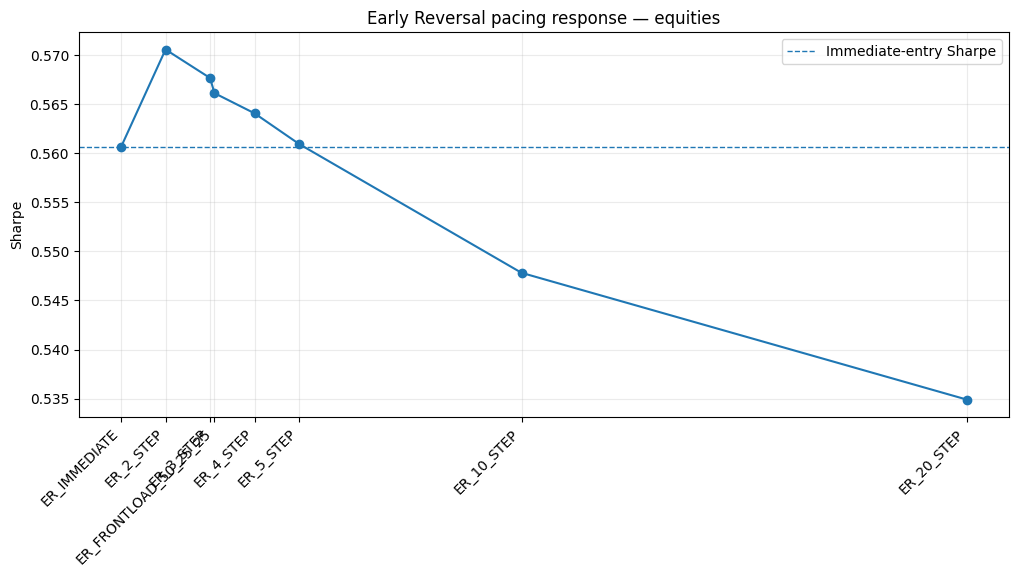

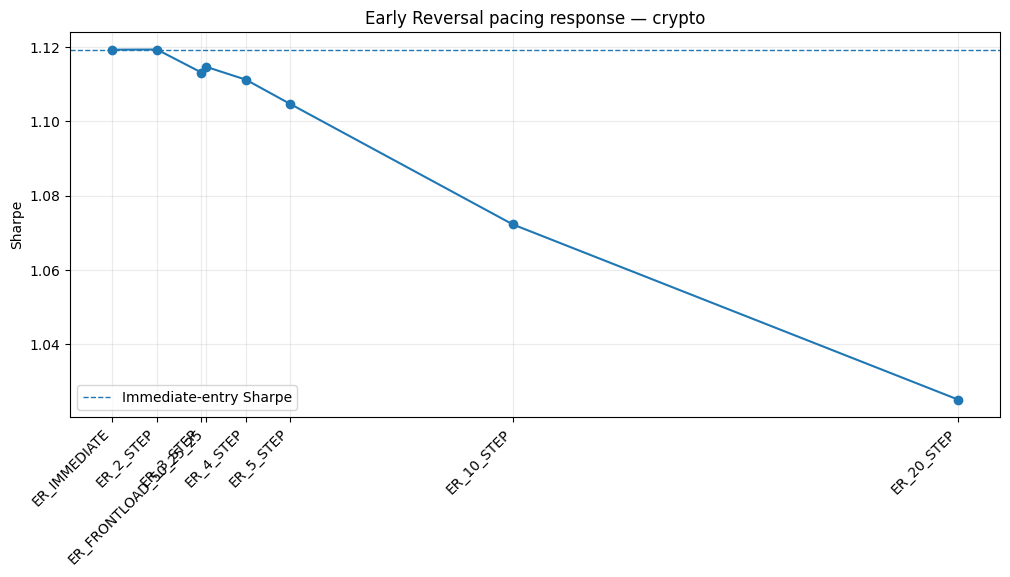

In [13]:
# ============================================================
# 14.13 — PACING RESPONSE CURVES
# ============================================================
STEP_ORDER = {
    "ER_IMMEDIATE": 1,
    "ER_2_STEP": 2,
    "ER_3_STEP": 3,
    "ER_FRONTLOAD_50_25_25": 3.1,
    "ER_4_STEP": 4,
    "ER_5_STEP": 5,
    "ER_10_STEP": 10,
    "ER_20_STEP": 20,
}

for asset_class in ["equities", "crypto"]:
    g = asset_class_performance[
        asset_class_performance["asset_class"] == asset_class
    ].copy()

    if g.empty:
        continue

    g["x"] = g["architecture"].map(STEP_ORDER)
    g = g.sort_values("x")

    plt.figure(figsize=(12, 5))
    plt.plot(g["x"], g["sharpe"], marker="o")
    plt.axhline(
        g.loc[g["architecture"] == "ER_IMMEDIATE", "sharpe"].iloc[0],
        linestyle="--",
        linewidth=1,
        label="Immediate-entry Sharpe"
    )
    plt.xticks(g["x"], g["architecture"], rotation=45, ha="right")
    plt.ylabel("Sharpe")
    plt.title(f"Early Reversal pacing response — {asset_class}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## 14.14 Early-Reversal event path study

For each Early Reversal start, measure underlying forward returns at:

- 1 week
- 2 weeks
- 3 weeks
- 5 weeks
- 10 weeks
- 20 weeks

Events are also classified by what happens after the reversal begins.


In [14]:
# ============================================================
# 14.14 — EVENT-LEVEL FORWARD RETURN PATHS
# ============================================================
HORIZONS = [1, 2, 3, 5, 10, 20]

# Build weekly market-return lookup.
ret_lookup = weekly_returns.copy()

event_rows = []

for ticker, g in sig.groupby(TICKER_COL):
    g = g.sort_values(DATE_COL).reset_index(drop=True)

    event_indices = g.index[g["start_early_reversal"]].tolist()

    for idx in event_indices:
        event_date = g.loc[idx, DATE_COL]
        asset_class = g.loc[idx, ASSET_CLASS_COL]

        row = {
            "ticker": ticker,
            "asset_class": asset_class,
            "event_date": event_date,
        }

        if ticker not in ret_lookup.columns:
            continue

        for h in HORIZONS:
            future_dates = g.loc[idx + 1: idx + h, DATE_COL]
            rr = ret_lookup.reindex(future_dates)[ticker].dropna()

            if len(rr):
                row[f"fwd_{h}w"] = float((1 + rr).prod() - 1)
            else:
                row[f"fwd_{h}w"] = np.nan

        # Classify the first non-EARLY_REVERSAL state after the event.
        future_states = g.loc[idx + 1:, STATE_COL]
        next_non_er = future_states[future_states != "EARLY_REVERSAL"]

        if len(next_non_er) == 0:
            outcome = "UNRESOLVED"
        else:
            nxt = str(next_non_er.iloc[0])

            if nxt in {"HELD_NEUTRAL", "PULLBACK", "PROFIT_TAKING"}:
                outcome = "SUCCESSFUL_CONTINUATION"
            elif nxt in {"OUT", "STANDBY"}:
                outcome = "FAILED_OR_ABORTED"
            else:
                outcome = f"OTHER_{nxt}"

        row["event_outcome"] = outcome
        event_rows.append(row)

event_study = pd.DataFrame(event_rows)

display(event_study.head())


,ticker,asset_class,event_date,fwd_1w,fwd_2w,fwd_3w,fwd_5w,fwd_10w,fwd_20w,event_outcome
0,BTC-USD,crypto,2016-11-18,-0.013220,0.035071,0.028219,0.226720,0.223747,0.565891,SUCCESSFUL_CONTINUATION
1,BTC-USD,crypto,2019-04-05,0.010495,0.053037,0.048180,0.266479,0.726104,1.066433,SUCCESSFUL_CONTINUATION
2,BTC-USD,crypto,2023-03-17,0.002529,0.038454,0.018303,-0.005361,-0.025694,0.060172,SUCCESSFUL_CONTINUATION
3,DBC,commodities,2008-05-23,-0.030368,0.005978,0.042563,0.090148,-0.044715,-0.345768,SUCCESSFUL_CONTINUATION
4,DBC,commodities,2009-05-29,0.028412,0.026690,-0.001291,-0.051657,0.002583,0.028842,SUCCESSFUL_CONTINUATION


In [15]:
# ============================================================
# 14.15 — EVENT-STUDY SUMMARY
# ============================================================
event_summary_rows = []

for (asset_class, outcome), g in event_study.groupby(
    ["asset_class", "event_outcome"]
):
    row = {
        "asset_class": asset_class,
        "event_outcome": outcome,
        "events": len(g),
    }

    for h in HORIZONS:
        x = g[f"fwd_{h}w"].dropna()
        row[f"mean_{h}w"] = x.mean() if len(x) else np.nan
        row[f"median_{h}w"] = x.median() if len(x) else np.nan
        row[f"positive_rate_{h}w"] = (x > 0).mean() if len(x) else np.nan

    event_summary_rows.append(row)

event_summary = pd.DataFrame(event_summary_rows)

display(
    event_summary[
        event_summary["asset_class"].isin(["equities", "crypto"])
    ]
)


,asset_class,event_outcome,events,mean_1w,median_1w,positive_rate_1w,mean_2w,median_2w,positive_rate_2w,mean_3w,...,positive_rate_3w,mean_5w,median_5w,positive_rate_5w,mean_10w,median_10w,positive_rate_10w,mean_20w,median_20w,positive_rate_20w
2,crypto,SUCCESSFUL_CONTINUATION,3,-0.000066,0.002529,0.666667,0.042187,0.038454,1.0,0.031567,...,1.00,0.162612,0.226720,0.666667,0.308052,0.223747,0.666667,0.564165,0.565891,1.00
3,equities,FAILED_OR_ABORTED,1,-0.045674,-0.045674,0.000000,-0.073607,-0.073607,0.0,-0.059057,...,0.00,-0.029230,-0.029230,0.000000,0.043495,0.043495,1.000000,0.074394,0.074394,1.00
4,equities,SUCCESSFUL_CONTINUATION,20,-0.004472,-0.004384,0.450000,0.006070,0.005405,0.7,0.009922,...,0.55,0.022521,0.023905,0.750000,0.022622,0.017314,0.700000,0.050313,0.026901,0.65


## 14.16 Event-level cost of slower entry

For each Early Reversal event, compare the realised strategy return during the first 20 weeks under each pacing architecture.

This directly measures the economic trade-off:

- protection from failed reversals;
- foregone upside in fast successful reversals.


In [16]:
# ============================================================
# 14.16 — EVENT-LEVEL PACING P&L
# ============================================================
event_pnl_rows = []

strategy_indexed = (
    strategy_long
    .set_index(["architecture", TICKER_COL, DATE_COL])
    .sort_index()
)

for _, event in event_study.iterrows():
    ticker = event["ticker"]
    event_date = pd.Timestamp(event["event_date"])
    asset_class = event["asset_class"]
    outcome = event["event_outcome"]

    ticker_dates = sig[sig[TICKER_COL] == ticker][DATE_COL].sort_values()
    future_dates = ticker_dates[ticker_dates > event_date].head(20)

    for architecture in PACING_SCHEDULES:
        idx = pd.MultiIndex.from_product(
            [[architecture], [ticker], future_dates],
            names=["architecture", TICKER_COL, DATE_COL]
        )

        rr = (
            strategy_indexed
            .reindex(idx)["strategy_return"]
            .dropna()
        )

        event_pnl_rows.append({
            "ticker": ticker,
            "asset_class": asset_class,
            "event_date": event_date,
            "event_outcome": outcome,
            "architecture": architecture,
            "first_20w_strategy_return": (
                (1 + rr).prod() - 1 if len(rr) else np.nan
            ),
        })

event_pnl = pd.DataFrame(event_pnl_rows)

event_pnl_summary = (
    event_pnl
    .groupby(["asset_class", "event_outcome", "architecture"])
    ["first_20w_strategy_return"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(
    event_pnl_summary[
        event_pnl_summary["asset_class"].isin(["equities", "crypto"])
    ]
)


,asset_class,event_outcome,architecture,count,mean,median
16,crypto,SUCCESSFUL_CONTINUATION,ER_10_STEP,3,0.370365,0.425206
17,crypto,SUCCESSFUL_CONTINUATION,ER_20_STEP,3,0.195892,0.269710
18,crypto,SUCCESSFUL_CONTINUATION,ER_2_STEP,3,0.563639,0.576380
19,crypto,SUCCESSFUL_CONTINUATION,ER_3_STEP,3,0.541994,0.555307
20,crypto,SUCCESSFUL_CONTINUATION,ER_4_STEP,3,0.534519,0.547303
21,crypto,SUCCESSFUL_CONTINUATION,ER_5_STEP,3,0.511260,0.537710
22,crypto,SUCCESSFUL_CONTINUATION,ER_FRONTLOAD_50_25_25,3,0.547537,0.557994
23,crypto,SUCCESSFUL_CONTINUATION,ER_IMMEDIATE,3,0.564165,0.565891
24,equities,FAILED_OR_ABORTED,ER_10_STEP,1,0.102107,0.102107
25,equities,FAILED_OR_ABORTED,ER_20_STEP,1,0.075818,0.075818


## 14.17 Subperiod stability

Use broad, economically distinct periods rather than optimised cut points.


In [17]:
# ============================================================
# 14.17 — SUBPERIOD PERFORMANCE
# ============================================================
SUBPERIODS = {
    "2006-2011": ("2006-01-01", "2011-12-31"),
    "2012-2017": ("2012-01-01", "2017-12-31"),
    "2018-2025": ("2018-01-01", "2025-12-31"),
}

subperiod_rows = []

for (architecture, asset_class), g in asset_class_weekly.groupby(
    ["architecture", ASSET_CLASS_COL]
):
    s = g.set_index(DATE_COL)["strategy_return"].sort_index()

    for period, (start, end) in SUBPERIODS.items():
        r = s.loc[start:end].dropna()

        if len(r) < 26:
            continue

        subperiod_rows.append({
            "architecture": architecture,
            "asset_class": asset_class,
            "period": period,
            **metrics(r),
        })

subperiod_performance = pd.DataFrame(subperiod_rows)

display(
    subperiod_performance[
        subperiod_performance["asset_class"].isin(["equities", "crypto"])
    ].sort_values(
        ["asset_class", "period", "sharpe"],
        ascending=[True, True, False]
    )
)


,architecture,asset_class,period,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,best_week,worst_week,positive_week_rate
31,ER_2_STEP,crypto,2012-2017,171,1.472724,0.574952,1.845450,2.385067,-0.264684,0.509658,-0.218847,0.233918
101,ER_IMMEDIATE,crypto,2012-2017,171,1.467709,0.575058,1.841613,2.397686,-0.264684,0.509658,-0.218847,0.233918
87,ER_FRONTLOAD_50_25_25,crypto,2012-2017,171,1.463917,0.574806,1.839447,2.376704,-0.264684,0.509658,-0.218847,0.233918
45,ER_3_STEP,crypto,2012-2017,171,1.462624,0.574744,1.838651,2.369469,-0.264684,0.509658,-0.218847,0.233918
59,ER_4_STEP,crypto,2012-2017,171,1.458764,0.574671,1.836027,2.358378,-0.264684,0.509658,-0.218847,0.233918
73,ER_5_STEP,crypto,2012-2017,171,1.454118,0.574656,1.832704,2.349580,-0.264684,0.509658,-0.218847,0.233918
3,ER_10_STEP,crypto,2012-2017,171,1.398067,0.567451,1.807767,2.263738,-0.264684,0.509658,-0.218847,0.233918
17,ER_20_STEP,crypto,2012-2017,171,1.315283,0.554767,1.771832,2.149059,-0.257831,0.509658,-0.218847,0.233918
102,ER_IMMEDIATE,crypto,2018-2025,417,0.359530,0.573409,0.824173,1.113640,-0.650954,0.388895,-0.390115,0.436451
32,ER_2_STEP,crypto,2018-2025,417,0.358434,0.573412,0.822752,1.111727,-0.650954,0.388895,-0.390115,0.436451


## 14.18 Leave-one-year-out robustness

For every pacing architecture, remove each calendar year and recompute Sharpe.

This is primarily compared against immediate entry.


In [18]:
# ============================================================
# 14.18 — LEAVE-ONE-YEAR-OUT
# ============================================================
loo_rows = []

for (architecture, asset_class), g in asset_class_weekly.groupby(
    ["architecture", ASSET_CLASS_COL]
):
    s = g.set_index(DATE_COL)["strategy_return"].dropna().sort_index()

    years = sorted(s.index.year.unique())

    for excluded_year in years:
        r = s[s.index.year != excluded_year]

        if len(r) < 52:
            continue

        loo_rows.append({
            "architecture": architecture,
            "asset_class": asset_class,
            "excluded_year": int(excluded_year),
            "sharpe": sharpe(r),
            "cagr": cagr(r),
            "max_drawdown": max_drawdown(r),
        })

loo = pd.DataFrame(loo_rows)

loo_delta_rows = []

for asset_class in loo["asset_class"].dropna().unique():
    base = loo[
        (loo["asset_class"] == asset_class)
        & (loo["architecture"] == "ER_IMMEDIATE")
    ][["excluded_year", "sharpe"]].rename(
        columns={"sharpe": "immediate_sharpe"}
    )

    for architecture in PACING_SCHEDULES:
        x = loo[
            (loo["asset_class"] == asset_class)
            & (loo["architecture"] == architecture)
        ][["excluded_year", "sharpe"]]

        merged = x.merge(base, on="excluded_year", how="inner")

        if merged.empty:
            continue

        gap = merged["sharpe"] - merged["immediate_sharpe"]

        loo_delta_rows.append({
            "asset_class": asset_class,
            "architecture": architecture,
            "years": len(gap),
            "share_year_exclusions_beating_immediate": (gap > 0).mean(),
            "median_sharpe_gap": gap.median(),
            "min_sharpe_gap": gap.min(),
            "max_sharpe_gap": gap.max(),
        })

loo_summary = pd.DataFrame(loo_delta_rows)

display(
    loo_summary[
        loo_summary["asset_class"].isin(["equities", "crypto"])
    ].sort_values(
        ["asset_class", "share_year_exclusions_beating_immediate",
         "median_sharpe_gap"],
        ascending=[True, False, False]
    )
)


,asset_class,architecture,years,share_year_exclusions_beating_immediate,median_sharpe_gap,min_sharpe_gap,max_sharpe_gap
9,crypto,ER_2_STEP,12,0.916667,0.000051,-0.001069,0.000944
8,crypto,ER_IMMEDIATE,12,0.000000,0.000000,0.000000,0.000000
15,crypto,ER_FRONTLOAD_50_25_25,12,0.000000,-0.004883,-0.005717,-0.002443
10,crypto,ER_3_STEP,12,0.000000,-0.006541,-0.007650,-0.003277
11,crypto,ER_4_STEP,12,0.000000,-0.008596,-0.010065,-0.004288
12,crypto,ER_5_STEP,12,0.000000,-0.015562,-0.018368,-0.008102
13,crypto,ER_10_STEP,12,0.000000,-0.049717,-0.067773,-0.015364
14,crypto,ER_20_STEP,12,0.000000,-0.099206,-0.124502,-0.030706
17,equities,ER_2_STEP,21,1.000000,0.010304,0.000575,0.015514
18,equities,ER_3_STEP,21,0.952381,0.007205,-0.001768,0.012874


## 14.19 Moving-block bootstrap versus immediate entry

Joint 13-week moving blocks preserve serial dependence better than IID resampling.

The bootstrap asks whether a staged architecture tends to outperform **immediate entry**, not whether it is the global optimum.


In [19]:
# ============================================================
# 14.19 — MOVING-BLOCK BOOTSTRAP
# ============================================================
BOOTSTRAP_ITERATIONS = 5000
BLOCK_WEEKS = 13
RANDOM_SEED = 20260905

rng = np.random.default_rng(RANDOM_SEED)

def moving_block_sample(data, block_len, rng):
    n = len(data)
    starts = np.arange(0, n - block_len + 1)

    chunks = []
    total = 0

    while total < n:
        s = int(rng.choice(starts))
        block = data[s:s + block_len]
        chunks.append(block)
        total += len(block)

    return np.vstack(chunks)[:n]

bootstrap_rows = []

for asset_class in ["equities", "crypto"]:
    pivot = (
        asset_class_weekly[
            asset_class_weekly[ASSET_CLASS_COL] == asset_class
        ]
        .pivot(
            index=DATE_COL,
            columns="architecture",
            values="strategy_return"
        )
        .sort_index()
    )

    if "ER_IMMEDIATE" not in pivot.columns:
        continue

    for architecture in PACING_SCHEDULES:
        if architecture == "ER_IMMEDIATE" or architecture not in pivot.columns:
            continue

        pair = pivot[["ER_IMMEDIATE", architecture]].dropna()
        arr = pair.to_numpy()

        if len(arr) < BLOCK_WEEKS:
            continue

        for i in range(BOOTSTRAP_ITERATIONS):
            sample = moving_block_sample(arr, BLOCK_WEEKS, rng)

            immediate = pd.Series(sample[:, 0])
            staged = pd.Series(sample[:, 1])

            bootstrap_rows.append({
                "asset_class": asset_class,
                "architecture": architecture,
                "iteration": i,
                "sharpe_gap": sharpe(staged) - sharpe(immediate),
                "cagr_gap": cagr(staged) - cagr(immediate),
                "sortino_gap": sortino(staged) - sortino(immediate),
                "max_drawdown_gap": (
                    max_drawdown(staged) - max_drawdown(immediate)
                ),
            })

bootstrap = pd.DataFrame(bootstrap_rows)

bootstrap_summary = (
    bootstrap
    .groupby(["asset_class", "architecture"])
    .agg(
        P_sharpe_gap_gt_0=("sharpe_gap", lambda x: (x > 0).mean()),
        P_cagr_gap_gt_0=("cagr_gap", lambda x: (x > 0).mean()),
        P_sortino_gap_gt_0=("sortino_gap", lambda x: (x > 0).mean()),
        P_maxdd_better=("max_drawdown_gap", lambda x: (x > 0).mean()),
        median_sharpe_gap=("sharpe_gap", "median"),
        sharpe_gap_2_5=("sharpe_gap", lambda x: x.quantile(0.025)),
        sharpe_gap_97_5=("sharpe_gap", lambda x: x.quantile(0.975)),
        median_cagr_gap=("cagr_gap", "median"),
    )
    .reset_index()
)

display(bootstrap_summary)


,asset_class,architecture,P_sharpe_gap_gt_0,P_cagr_gap_gt_0,P_sortino_gap_gt_0,P_maxdd_better,median_sharpe_gap,sharpe_gap_2_5,sharpe_gap_97_5,median_cagr_gap
0,crypto,ER_10_STEP,0.0250,0.0156,0.0156,0.2404,-0.043523,-0.123559,8.221292e-07,-0.045696
1,crypto,ER_20_STEP,0.0250,0.0136,0.0102,0.3546,-0.087369,-0.241514,6.104848e-06,-0.093729
2,crypto,ER_2_STEP,0.4936,0.4936,0.2206,0.2410,0.000000,-0.002525,3.079690e-03,0.000000
3,crypto,ER_3_STEP,0.0060,0.0060,0.0024,0.1884,-0.005888,-0.015348,0.000000e+00,-0.005565
4,crypto,ER_4_STEP,0.0102,0.0096,0.0076,0.2012,-0.007689,-0.019895,0.000000e+00,-0.007253
5,crypto,ER_5_STEP,0.0018,0.0018,0.0014,0.2118,-0.014032,-0.034479,-3.551967e-04,-0.013437
6,crypto,ER_FRONTLOAD_50_25_25,0.0054,0.0054,0.0028,0.1818,-0.004399,-0.011662,0.000000e+00,-0.004199
7,equities,ER_10_STEP,0.2542,0.1148,0.1206,0.4616,-0.011995,-0.048445,2.507803e-02,-0.003189
8,equities,ER_20_STEP,0.2018,0.0556,0.0722,0.5602,-0.024211,-0.084170,3.187061e-02,-0.006834
9,equities,ER_2_STEP,0.8216,0.7914,0.7876,0.4860,0.008718,-0.008051,3.521717e-02,0.001063


## 14.20 Cross-market consistency inside equities

Because the equity sleeve contains multiple regional equity markets, a robust pacing improvement should not depend entirely on SPY.


In [20]:
# ============================================================
# 14.2 — DISCOVER & LOAD NOTEBOOK 02 SIGNAL PANEL
# ============================================================

def find_candidate_files(root, patterns):
    found = []
    if root.exists():
        for pattern in patterns:
            found.extend(root.rglob(pattern))
    return list(dict.fromkeys(found))


# ------------------------------------------------------------
# 1) Discover candidate parquet files
# ------------------------------------------------------------
candidates = find_candidate_files(
    PATHS["data_processed"],
    [
        "*signal*.parquet",
        "*superbcommand*.parquet",
        "*state*.parquet",
        "*.parquet",
    ],
)

if not candidates:
    raise FileNotFoundError(
        f"No parquet files found under {PATHS['data_processed']}"
    )


# ------------------------------------------------------------
# 2) Score candidates by the distinctive Notebook 02 schema
# ------------------------------------------------------------
#
# IMPORTANT:
# We do NOT require a perfect schema match here.
# Earlier notebooks evolved and some saved panels omit a small number
# of convenience fields. The correct signal panel is instead identified
# by a combination of:
#
#   • core price fields
#   • SuperbCommand indicator fields
#   • event / regime fields
#   • row count / column richness
#
# Cell 14.3 performs the strict downstream field validation.
# ------------------------------------------------------------

CORE_FIELDS = {
    "open",
    "high",
    "low",
    "close",
}

SIGNAL_FIELDS = {
    "oscillator",
    "signal_line",
    "fast_ma",
    "slow_ma",
}

REGIME_FIELDS = {
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "position_held",
    "start_early_reversal",
    "standby_active",
    "zone_mode",
}

IDENTITY_FIELDS = {
    "ticker",
    "date",
}

schema_rows = []

for p in candidates:
    try:
        df = pd.read_parquet(p)
        cols = {str(c) for c in df.columns}

        core_hits = len(CORE_FIELDS.intersection(cols))
        signal_hits = len(SIGNAL_FIELDS.intersection(cols))
        regime_hits = len(REGIME_FIELDS.intersection(cols))
        identity_hits = len(IDENTITY_FIELDS.intersection(cols))

        score = (
            core_hits * 2
            + signal_hits * 3
            + regime_hits * 5
            + identity_hits * 5
        )

        # Rich Notebook 02 panels are wide. Reward that modestly.
        if len(df.columns) >= 40:
            score += 10

        # The research panel should also be long enough to cover the universe.
        if len(df) >= 5000:
            score += 5

        schema_rows.append({
            "path": str(p),
            "rows": len(df),
            "columns": len(df.columns),
            "score": score,
            "identity_hits": identity_hits,
            "core_hits": core_hits,
            "signal_hits": signal_hits,
            "regime_hits": regime_hits,
            "column_names": list(map(str, df.columns)),
        })

    except Exception as e:
        schema_rows.append({
            "path": str(p),
            "rows": np.nan,
            "columns": np.nan,
            "score": -1,
            "identity_hits": 0,
            "core_hits": 0,
            "signal_hits": 0,
            "regime_hits": 0,
            "column_names": [],
            "error": str(e),
        })


candidate_schema = pd.DataFrame(schema_rows).sort_values(
    ["score", "columns", "rows"],
    ascending=[False, False, False],
)

display(
    candidate_schema[
        [
            "path",
            "rows",
            "columns",
            "score",
            "identity_hits",
            "core_hits",
            "signal_hits",
            "regime_hits",
            "column_names",
        ]
    ].head(15)
)


# ------------------------------------------------------------
# 3) Select the strongest Notebook 02-like panel
# ------------------------------------------------------------

best = candidate_schema.iloc[0]

# Minimum safeguard:
# must have OHLC / close information, several signal-engine fields,
# and several regime/event fields.
if (
    best["core_hits"] < 1
    or best["signal_hits"] < 2
    or best["regime_hits"] < 3
):
    raise FileNotFoundError(
        "Notebook 14 could not identify a sufficiently convincing "
        "Notebook 02 SuperbCommand signal panel."
    )

SIGNAL_PATH = Path(best["path"])
signals = pd.read_parquet(SIGNAL_PATH)


# ------------------------------------------------------------
# 4) Report exactly what was selected
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("NOTEBOOK 14 — UPSTREAM ARTIFACT")
print("=" * 78)

print("\nSelected signal panel:")
print(SIGNAL_PATH)

print("\nShape:", signals.shape)

print("\nColumns:")
print(list(signals.columns))

selected_cols = set(map(str, signals.columns))

print("\nExpected field availability:")
for field in [
    "ticker",
    "date",
    "close",
    "position_held",
    "standby_active",
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "start_early_reversal",
]:
    print(f"{field:<28} {field in selected_cols}")

print(
    "\nWeekly market returns will be reconstructed directly from the "
    "selected panel's close series once Cell 14.3 has normalised the "
    "ticker/date structure."
)


,path,rows,columns,score,identity_hits,core_hits,signal_hits,regime_hits,column_names
0,/content/drive/MyDrive/Colab Notebooks/SuperbC...,11370,55,70,0,4,4,7,"[open, high, low, close, smoothed_price, fast_..."
4,/content/drive/MyDrive/Colab Notebooks/SuperbC...,11370,24,15,2,0,0,0,"[date, original_close, original_return, origin..."
3,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,154,10,0,0,0,0,"[('BTC-USD', 'CORE', 'long_cash'), ('BTC-USD',..."
5,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,44,10,0,0,0,0,"[('hier_equal_weight', 'BTC-USD'), ('hier_equa..."
1,/content/drive/MyDrive/Colab Notebooks/SuperbC...,6567,11,5,0,0,0,0,"[SPY, EFA, EEM, SHY, IEF, TLT, TIP, GLD, DBC, ..."
2,/content/drive/MyDrive/Colab Notebooks/SuperbC...,6567,11,5,0,0,0,0,"[SPY, EFA, EEM, SHY, IEF, TLT, TIP, GLD, DBC, ..."
12,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,25,0,0,0,0,0,"[('commodities', 'SC_CORE'), ('commodities', '..."
6,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,12,0,0,0,0,0,"[('CORE', 'hier_equal_weight'), ('CORE', 'hier..."
8,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,10,0,0,0,0,0,"[('SUPERBCOMMAND_CORE', 'hier_equal_weight'), ..."
16,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1016,7,0,0,0,0,0,"[DUAL_RECONSTRUCTED, EQUITIES_SC__FROZEN_WEIGH..."



NOTEBOOK 14 — UPSTREAM ARTIFACT

Selected signal panel:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/superbcommand_weekly_signal_panel.parquet

Shape: (11370, 55)

Columns:
['open', 'high', 'low', 'close', 'smoothed_price', 'fast_ma', 'slow_ma', 'oscillator', 'signal_line', 'spread', 'oscillator_slope', 'signal_slope', 'osc_rising', 'osc_falling', 'signal_rising', 'signal_falling', 'osc_turns_red', 'spread_std', 'upper_bb', 'lower_bb', 'atr', 'assigned_centroid', 'vol_cluster', 'supertrend', 'supertrend_dir', 'supertrend_bullish', 'supertrend_bearish', 'signal_cross_above_zero', 'osc_cross_above_signal', 'osc_cross_above_lower_bb', 'osc_cross_below_upper_bb', 'start_early_reversal', 'start_pullback', 'end_early_reversal', 'end_pullback', 'start_profit_taking', 'end_profit_taking', 'position_entry_event', 'position_exit_event', 'standby_anchor_event', 'position_held', 'standby_active', 'early_reversal_active', 'pullback_active', 'profit_t

## 14.21 Plateau / parsimony diagnostics

No winner is declared mechanically.

The table asks whether staged entry is supported across multiple dimensions.

A particularly attractive result would be **adjacent schedules**—for example 3-, 4- and 5-step—showing similar improvements. That would imply the research is identifying a useful *region* rather than fitting an exact historical optimum.


In [21]:
# ============================================================
# 14.2 — DISCOVER & LOAD NOTEBOOK 02 SIGNAL PANEL
# ============================================================

def find_candidate_files(root, patterns):
    found = []
    if root.exists():
        for pattern in patterns:
            found.extend(root.rglob(pattern))
    return list(dict.fromkeys(found))


# ------------------------------------------------------------
# 1) Discover candidate parquet files
# ------------------------------------------------------------
candidates = find_candidate_files(
    PATHS["data_processed"],
    [
        "*signal*.parquet",
        "*superbcommand*.parquet",
        "*state*.parquet",
        "*.parquet",
    ],
)

if not candidates:
    raise FileNotFoundError(
        f"No parquet files found under {PATHS['data_processed']}"
    )


# ------------------------------------------------------------
# 2) Score candidates by the distinctive Notebook 02 schema
# ------------------------------------------------------------
#
# IMPORTANT:
# We do NOT require a perfect schema match here.
# Earlier notebooks evolved and some saved panels omit a small number
# of convenience fields. The correct signal panel is instead identified
# by a combination of:
#
#   • core price fields
#   • SuperbCommand indicator fields
#   • event / regime fields
#   • row count / column richness
#
# Cell 14.3 performs the strict downstream field validation.
# ------------------------------------------------------------

CORE_FIELDS = {
    "open",
    "high",
    "low",
    "close",
}

SIGNAL_FIELDS = {
    "oscillator",
    "signal_line",
    "fast_ma",
    "slow_ma",
}

REGIME_FIELDS = {
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "position_held",
    "start_early_reversal",
    "standby_active",
    "zone_mode",
}

IDENTITY_FIELDS = {
    "ticker",
    "date",
}

schema_rows = []

for p in candidates:
    try:
        df = pd.read_parquet(p)
        cols = {str(c) for c in df.columns}

        core_hits = len(CORE_FIELDS.intersection(cols))
        signal_hits = len(SIGNAL_FIELDS.intersection(cols))
        regime_hits = len(REGIME_FIELDS.intersection(cols))
        identity_hits = len(IDENTITY_FIELDS.intersection(cols))

        score = (
            core_hits * 2
            + signal_hits * 3
            + regime_hits * 5
            + identity_hits * 5
        )

        # Rich Notebook 02 panels are wide. Reward that modestly.
        if len(df.columns) >= 40:
            score += 10

        # The research panel should also be long enough to cover the universe.
        if len(df) >= 5000:
            score += 5

        schema_rows.append({
            "path": str(p),
            "rows": len(df),
            "columns": len(df.columns),
            "score": score,
            "identity_hits": identity_hits,
            "core_hits": core_hits,
            "signal_hits": signal_hits,
            "regime_hits": regime_hits,
            "column_names": list(map(str, df.columns)),
        })

    except Exception as e:
        schema_rows.append({
            "path": str(p),
            "rows": np.nan,
            "columns": np.nan,
            "score": -1,
            "identity_hits": 0,
            "core_hits": 0,
            "signal_hits": 0,
            "regime_hits": 0,
            "column_names": [],
            "error": str(e),
        })


candidate_schema = pd.DataFrame(schema_rows).sort_values(
    ["score", "columns", "rows"],
    ascending=[False, False, False],
)

display(
    candidate_schema[
        [
            "path",
            "rows",
            "columns",
            "score",
            "identity_hits",
            "core_hits",
            "signal_hits",
            "regime_hits",
            "column_names",
        ]
    ].head(15)
)


# ------------------------------------------------------------
# 3) Select the strongest Notebook 02-like panel
# ------------------------------------------------------------

best = candidate_schema.iloc[0]

# Minimum safeguard:
# must have OHLC / close information, several signal-engine fields,
# and several regime/event fields.
if (
    best["core_hits"] < 1
    or best["signal_hits"] < 2
    or best["regime_hits"] < 3
):
    raise FileNotFoundError(
        "Notebook 14 could not identify a sufficiently convincing "
        "Notebook 02 SuperbCommand signal panel."
    )

SIGNAL_PATH = Path(best["path"])
signals = pd.read_parquet(SIGNAL_PATH)


# ------------------------------------------------------------
# 4) Report exactly what was selected
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("NOTEBOOK 14 — UPSTREAM ARTIFACT")
print("=" * 78)

print("\nSelected signal panel:")
print(SIGNAL_PATH)

print("\nShape:", signals.shape)

print("\nColumns:")
print(list(signals.columns))

selected_cols = set(map(str, signals.columns))

print("\nExpected field availability:")
for field in [
    "ticker",
    "date",
    "close",
    "position_held",
    "standby_active",
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "start_early_reversal",
]:
    print(f"{field:<28} {field in selected_cols}")

print(
    "\nWeekly market returns will be reconstructed directly from the "
    "selected panel's close series once Cell 14.3 has normalised the "
    "ticker/date structure."
)


,path,rows,columns,score,identity_hits,core_hits,signal_hits,regime_hits,column_names
0,/content/drive/MyDrive/Colab Notebooks/SuperbC...,11370,55,70,0,4,4,7,"[open, high, low, close, smoothed_price, fast_..."
4,/content/drive/MyDrive/Colab Notebooks/SuperbC...,11370,24,15,2,0,0,0,"[date, original_close, original_return, origin..."
3,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,154,10,0,0,0,0,"[('BTC-USD', 'CORE', 'long_cash'), ('BTC-USD',..."
5,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,44,10,0,0,0,0,"[('hier_equal_weight', 'BTC-USD'), ('hier_equa..."
1,/content/drive/MyDrive/Colab Notebooks/SuperbC...,6567,11,5,0,0,0,0,"[SPY, EFA, EEM, SHY, IEF, TLT, TIP, GLD, DBC, ..."
2,/content/drive/MyDrive/Colab Notebooks/SuperbC...,6567,11,5,0,0,0,0,"[SPY, EFA, EEM, SHY, IEF, TLT, TIP, GLD, DBC, ..."
12,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,25,0,0,0,0,0,"[('commodities', 'SC_CORE'), ('commodities', '..."
6,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,12,0,0,0,0,0,"[('CORE', 'hier_equal_weight'), ('CORE', 'hier..."
8,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,10,0,0,0,0,0,"[('SUPERBCOMMAND_CORE', 'hier_equal_weight'), ..."
16,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1016,7,0,0,0,0,0,"[DUAL_RECONSTRUCTED, EQUITIES_SC__FROZEN_WEIGH..."



NOTEBOOK 14 — UPSTREAM ARTIFACT

Selected signal panel:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/superbcommand_weekly_signal_panel.parquet

Shape: (11370, 55)

Columns:
['open', 'high', 'low', 'close', 'smoothed_price', 'fast_ma', 'slow_ma', 'oscillator', 'signal_line', 'spread', 'oscillator_slope', 'signal_slope', 'osc_rising', 'osc_falling', 'signal_rising', 'signal_falling', 'osc_turns_red', 'spread_std', 'upper_bb', 'lower_bb', 'atr', 'assigned_centroid', 'vol_cluster', 'supertrend', 'supertrend_dir', 'supertrend_bullish', 'supertrend_bearish', 'signal_cross_above_zero', 'osc_cross_above_signal', 'osc_cross_above_lower_bb', 'osc_cross_below_upper_bb', 'start_early_reversal', 'start_pullback', 'end_early_reversal', 'end_pullback', 'start_profit_taking', 'end_profit_taking', 'position_entry_event', 'position_exit_event', 'standby_anchor_event', 'position_held', 'standby_active', 'early_reversal_active', 'pullback_active', 'profit_t

## 14.22 Research interpretation flags

These are diagnostic labels only.

They do **not** select a production setting.


In [22]:
# ============================================================
# 14.2 — DISCOVER & LOAD NOTEBOOK 02 SIGNAL PANEL
# ============================================================

def find_candidate_files(root, patterns):
    found = []
    if root.exists():
        for pattern in patterns:
            found.extend(root.rglob(pattern))
    return list(dict.fromkeys(found))


# ------------------------------------------------------------
# 1) Discover candidate parquet files
# ------------------------------------------------------------
candidates = find_candidate_files(
    PATHS["data_processed"],
    [
        "*signal*.parquet",
        "*superbcommand*.parquet",
        "*state*.parquet",
        "*.parquet",
    ],
)

if not candidates:
    raise FileNotFoundError(
        f"No parquet files found under {PATHS['data_processed']}"
    )


# ------------------------------------------------------------
# 2) Score candidates by the distinctive Notebook 02 schema
# ------------------------------------------------------------
#
# IMPORTANT:
# We do NOT require a perfect schema match here.
# Earlier notebooks evolved and some saved panels omit a small number
# of convenience fields. The correct signal panel is instead identified
# by a combination of:
#
#   • core price fields
#   • SuperbCommand indicator fields
#   • event / regime fields
#   • row count / column richness
#
# Cell 14.3 performs the strict downstream field validation.
# ------------------------------------------------------------

CORE_FIELDS = {
    "open",
    "high",
    "low",
    "close",
}

SIGNAL_FIELDS = {
    "oscillator",
    "signal_line",
    "fast_ma",
    "slow_ma",
}

REGIME_FIELDS = {
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "position_held",
    "start_early_reversal",
    "standby_active",
    "zone_mode",
}

IDENTITY_FIELDS = {
    "ticker",
    "date",
}

schema_rows = []

for p in candidates:
    try:
        df = pd.read_parquet(p)
        cols = {str(c) for c in df.columns}

        core_hits = len(CORE_FIELDS.intersection(cols))
        signal_hits = len(SIGNAL_FIELDS.intersection(cols))
        regime_hits = len(REGIME_FIELDS.intersection(cols))
        identity_hits = len(IDENTITY_FIELDS.intersection(cols))

        score = (
            core_hits * 2
            + signal_hits * 3
            + regime_hits * 5
            + identity_hits * 5
        )

        # Rich Notebook 02 panels are wide. Reward that modestly.
        if len(df.columns) >= 40:
            score += 10

        # The research panel should also be long enough to cover the universe.
        if len(df) >= 5000:
            score += 5

        schema_rows.append({
            "path": str(p),
            "rows": len(df),
            "columns": len(df.columns),
            "score": score,
            "identity_hits": identity_hits,
            "core_hits": core_hits,
            "signal_hits": signal_hits,
            "regime_hits": regime_hits,
            "column_names": list(map(str, df.columns)),
        })

    except Exception as e:
        schema_rows.append({
            "path": str(p),
            "rows": np.nan,
            "columns": np.nan,
            "score": -1,
            "identity_hits": 0,
            "core_hits": 0,
            "signal_hits": 0,
            "regime_hits": 0,
            "column_names": [],
            "error": str(e),
        })


candidate_schema = pd.DataFrame(schema_rows).sort_values(
    ["score", "columns", "rows"],
    ascending=[False, False, False],
)

display(
    candidate_schema[
        [
            "path",
            "rows",
            "columns",
            "score",
            "identity_hits",
            "core_hits",
            "signal_hits",
            "regime_hits",
            "column_names",
        ]
    ].head(15)
)


# ------------------------------------------------------------
# 3) Select the strongest Notebook 02-like panel
# ------------------------------------------------------------

best = candidate_schema.iloc[0]

# Minimum safeguard:
# must have OHLC / close information, several signal-engine fields,
# and several regime/event fields.
if (
    best["core_hits"] < 1
    or best["signal_hits"] < 2
    or best["regime_hits"] < 3
):
    raise FileNotFoundError(
        "Notebook 14 could not identify a sufficiently convincing "
        "Notebook 02 SuperbCommand signal panel."
    )

SIGNAL_PATH = Path(best["path"])
signals = pd.read_parquet(SIGNAL_PATH)


# ------------------------------------------------------------
# 4) Report exactly what was selected
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("NOTEBOOK 14 — UPSTREAM ARTIFACT")
print("=" * 78)

print("\nSelected signal panel:")
print(SIGNAL_PATH)

print("\nShape:", signals.shape)

print("\nColumns:")
print(list(signals.columns))

selected_cols = set(map(str, signals.columns))

print("\nExpected field availability:")
for field in [
    "ticker",
    "date",
    "close",
    "position_held",
    "standby_active",
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "start_early_reversal",
]:
    print(f"{field:<28} {field in selected_cols}")

print(
    "\nWeekly market returns will be reconstructed directly from the "
    "selected panel's close series once Cell 14.3 has normalised the "
    "ticker/date structure."
)


,path,rows,columns,score,identity_hits,core_hits,signal_hits,regime_hits,column_names
0,/content/drive/MyDrive/Colab Notebooks/SuperbC...,11370,55,70,0,4,4,7,"[open, high, low, close, smoothed_price, fast_..."
4,/content/drive/MyDrive/Colab Notebooks/SuperbC...,11370,24,15,2,0,0,0,"[date, original_close, original_return, origin..."
3,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,154,10,0,0,0,0,"[('BTC-USD', 'CORE', 'long_cash'), ('BTC-USD',..."
5,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,44,10,0,0,0,0,"[('hier_equal_weight', 'BTC-USD'), ('hier_equa..."
1,/content/drive/MyDrive/Colab Notebooks/SuperbC...,6567,11,5,0,0,0,0,"[SPY, EFA, EEM, SHY, IEF, TLT, TIP, GLD, DBC, ..."
2,/content/drive/MyDrive/Colab Notebooks/SuperbC...,6567,11,5,0,0,0,0,"[SPY, EFA, EEM, SHY, IEF, TLT, TIP, GLD, DBC, ..."
12,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,25,0,0,0,0,0,"[('commodities', 'SC_CORE'), ('commodities', '..."
6,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,12,0,0,0,0,0,"[('CORE', 'hier_equal_weight'), ('CORE', 'hier..."
8,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,10,0,0,0,0,0,"[('SUPERBCOMMAND_CORE', 'hier_equal_weight'), ..."
16,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1016,7,0,0,0,0,0,"[DUAL_RECONSTRUCTED, EQUITIES_SC__FROZEN_WEIGH..."



NOTEBOOK 14 — UPSTREAM ARTIFACT

Selected signal panel:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/superbcommand_weekly_signal_panel.parquet

Shape: (11370, 55)

Columns:
['open', 'high', 'low', 'close', 'smoothed_price', 'fast_ma', 'slow_ma', 'oscillator', 'signal_line', 'spread', 'oscillator_slope', 'signal_slope', 'osc_rising', 'osc_falling', 'signal_rising', 'signal_falling', 'osc_turns_red', 'spread_std', 'upper_bb', 'lower_bb', 'atr', 'assigned_centroid', 'vol_cluster', 'supertrend', 'supertrend_dir', 'supertrend_bullish', 'supertrend_bearish', 'signal_cross_above_zero', 'osc_cross_above_signal', 'osc_cross_above_lower_bb', 'osc_cross_below_upper_bb', 'start_early_reversal', 'start_pullback', 'end_early_reversal', 'end_pullback', 'start_profit_taking', 'end_profit_taking', 'position_entry_event', 'position_exit_event', 'standby_anchor_event', 'position_held', 'standby_active', 'early_reversal_active', 'pullback_active', 'profit_t

## 14.23 Save outputs


In [23]:
# ============================================================
# 14.2 — DISCOVER & LOAD NOTEBOOK 02 SIGNAL PANEL
# ============================================================

def find_candidate_files(root, patterns):
    found = []
    if root.exists():
        for pattern in patterns:
            found.extend(root.rglob(pattern))
    return list(dict.fromkeys(found))


# ------------------------------------------------------------
# 1) Discover candidate parquet files
# ------------------------------------------------------------
candidates = find_candidate_files(
    PATHS["data_processed"],
    [
        "*signal*.parquet",
        "*superbcommand*.parquet",
        "*state*.parquet",
        "*.parquet",
    ],
)

if not candidates:
    raise FileNotFoundError(
        f"No parquet files found under {PATHS['data_processed']}"
    )


# ------------------------------------------------------------
# 2) Score candidates by the distinctive Notebook 02 schema
# ------------------------------------------------------------
#
# IMPORTANT:
# We do NOT require a perfect schema match here.
# Earlier notebooks evolved and some saved panels omit a small number
# of convenience fields. The correct signal panel is instead identified
# by a combination of:
#
#   • core price fields
#   • SuperbCommand indicator fields
#   • event / regime fields
#   • row count / column richness
#
# Cell 14.3 performs the strict downstream field validation.
# ------------------------------------------------------------

CORE_FIELDS = {
    "open",
    "high",
    "low",
    "close",
}

SIGNAL_FIELDS = {
    "oscillator",
    "signal_line",
    "fast_ma",
    "slow_ma",
}

REGIME_FIELDS = {
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "position_held",
    "start_early_reversal",
    "standby_active",
    "zone_mode",
}

IDENTITY_FIELDS = {
    "ticker",
    "date",
}

schema_rows = []

for p in candidates:
    try:
        df = pd.read_parquet(p)
        cols = {str(c) for c in df.columns}

        core_hits = len(CORE_FIELDS.intersection(cols))
        signal_hits = len(SIGNAL_FIELDS.intersection(cols))
        regime_hits = len(REGIME_FIELDS.intersection(cols))
        identity_hits = len(IDENTITY_FIELDS.intersection(cols))

        score = (
            core_hits * 2
            + signal_hits * 3
            + regime_hits * 5
            + identity_hits * 5
        )

        # Rich Notebook 02 panels are wide. Reward that modestly.
        if len(df.columns) >= 40:
            score += 10

        # The research panel should also be long enough to cover the universe.
        if len(df) >= 5000:
            score += 5

        schema_rows.append({
            "path": str(p),
            "rows": len(df),
            "columns": len(df.columns),
            "score": score,
            "identity_hits": identity_hits,
            "core_hits": core_hits,
            "signal_hits": signal_hits,
            "regime_hits": regime_hits,
            "column_names": list(map(str, df.columns)),
        })

    except Exception as e:
        schema_rows.append({
            "path": str(p),
            "rows": np.nan,
            "columns": np.nan,
            "score": -1,
            "identity_hits": 0,
            "core_hits": 0,
            "signal_hits": 0,
            "regime_hits": 0,
            "column_names": [],
            "error": str(e),
        })


candidate_schema = pd.DataFrame(schema_rows).sort_values(
    ["score", "columns", "rows"],
    ascending=[False, False, False],
)

display(
    candidate_schema[
        [
            "path",
            "rows",
            "columns",
            "score",
            "identity_hits",
            "core_hits",
            "signal_hits",
            "regime_hits",
            "column_names",
        ]
    ].head(15)
)


# ------------------------------------------------------------
# 3) Select the strongest Notebook 02-like panel
# ------------------------------------------------------------

best = candidate_schema.iloc[0]

# Minimum safeguard:
# must have OHLC / close information, several signal-engine fields,
# and several regime/event fields.
if (
    best["core_hits"] < 1
    or best["signal_hits"] < 2
    or best["regime_hits"] < 3
):
    raise FileNotFoundError(
        "Notebook 14 could not identify a sufficiently convincing "
        "Notebook 02 SuperbCommand signal panel."
    )

SIGNAL_PATH = Path(best["path"])
signals = pd.read_parquet(SIGNAL_PATH)


# ------------------------------------------------------------
# 4) Report exactly what was selected
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("NOTEBOOK 14 — UPSTREAM ARTIFACT")
print("=" * 78)

print("\nSelected signal panel:")
print(SIGNAL_PATH)

print("\nShape:", signals.shape)

print("\nColumns:")
print(list(signals.columns))

selected_cols = set(map(str, signals.columns))

print("\nExpected field availability:")
for field in [
    "ticker",
    "date",
    "close",
    "position_held",
    "standby_active",
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "start_early_reversal",
]:
    print(f"{field:<28} {field in selected_cols}")

print(
    "\nWeekly market returns will be reconstructed directly from the "
    "selected panel's close series once Cell 14.3 has normalised the "
    "ticker/date structure."
)


,path,rows,columns,score,identity_hits,core_hits,signal_hits,regime_hits,column_names
0,/content/drive/MyDrive/Colab Notebooks/SuperbC...,11370,55,70,0,4,4,7,"[open, high, low, close, smoothed_price, fast_..."
4,/content/drive/MyDrive/Colab Notebooks/SuperbC...,11370,24,15,2,0,0,0,"[date, original_close, original_return, origin..."
3,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,154,10,0,0,0,0,"[('BTC-USD', 'CORE', 'long_cash'), ('BTC-USD',..."
5,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,44,10,0,0,0,0,"[('hier_equal_weight', 'BTC-USD'), ('hier_equa..."
1,/content/drive/MyDrive/Colab Notebooks/SuperbC...,6567,11,5,0,0,0,0,"[SPY, EFA, EEM, SHY, IEF, TLT, TIP, GLD, DBC, ..."
2,/content/drive/MyDrive/Colab Notebooks/SuperbC...,6567,11,5,0,0,0,0,"[SPY, EFA, EEM, SHY, IEF, TLT, TIP, GLD, DBC, ..."
12,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,25,0,0,0,0,0,"[('commodities', 'SC_CORE'), ('commodities', '..."
6,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,12,0,0,0,0,0,"[('CORE', 'hier_equal_weight'), ('CORE', 'hier..."
8,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,10,0,0,0,0,0,"[('SUPERBCOMMAND_CORE', 'hier_equal_weight'), ..."
16,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1016,7,0,0,0,0,0,"[DUAL_RECONSTRUCTED, EQUITIES_SC__FROZEN_WEIGH..."



NOTEBOOK 14 — UPSTREAM ARTIFACT

Selected signal panel:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/superbcommand_weekly_signal_panel.parquet

Shape: (11370, 55)

Columns:
['open', 'high', 'low', 'close', 'smoothed_price', 'fast_ma', 'slow_ma', 'oscillator', 'signal_line', 'spread', 'oscillator_slope', 'signal_slope', 'osc_rising', 'osc_falling', 'signal_rising', 'signal_falling', 'osc_turns_red', 'spread_std', 'upper_bb', 'lower_bb', 'atr', 'assigned_centroid', 'vol_cluster', 'supertrend', 'supertrend_dir', 'supertrend_bullish', 'supertrend_bearish', 'signal_cross_above_zero', 'osc_cross_above_signal', 'osc_cross_above_lower_bb', 'osc_cross_below_upper_bb', 'start_early_reversal', 'start_pullback', 'end_early_reversal', 'end_pullback', 'start_profit_taking', 'end_profit_taking', 'position_entry_event', 'position_exit_event', 'standby_anchor_event', 'position_held', 'standby_active', 'early_reversal_active', 'pullback_active', 'profit_t

## 14.24 Validation suite

Notebook 14 passes only if:

- 2026 is absent;
- all eight pacing architectures are present;
- each schedule sums to exactly 100%;
- the 10-step schedule is 10% × 10;
- the 20-step schedule is 5% × 20;
- implemented exposure is bounded between 0 and 1;
- the one-week lag is applied;
- event diagnostics exist;
- bootstrap uses 5,000 joint 13-week blocks;
- no signal hyperparameters were optimised;
- outputs are written.


In [24]:
# ============================================================
# 14.2 — DISCOVER & LOAD NOTEBOOK 02 SIGNAL PANEL
# ============================================================

def find_candidate_files(root, patterns):
    found = []
    if root.exists():
        for pattern in patterns:
            found.extend(root.rglob(pattern))
    return list(dict.fromkeys(found))


# ------------------------------------------------------------
# 1) Discover candidate parquet files
# ------------------------------------------------------------
candidates = find_candidate_files(
    PATHS["data_processed"],
    [
        "*signal*.parquet",
        "*superbcommand*.parquet",
        "*state*.parquet",
        "*.parquet",
    ],
)

if not candidates:
    raise FileNotFoundError(
        f"No parquet files found under {PATHS['data_processed']}"
    )


# ------------------------------------------------------------
# 2) Score candidates by the distinctive Notebook 02 schema
# ------------------------------------------------------------
#
# IMPORTANT:
# We do NOT require a perfect schema match here.
# Earlier notebooks evolved and some saved panels omit a small number
# of convenience fields. The correct signal panel is instead identified
# by a combination of:
#
#   • core price fields
#   • SuperbCommand indicator fields
#   • event / regime fields
#   • row count / column richness
#
# Cell 14.3 performs the strict downstream field validation.
# ------------------------------------------------------------

CORE_FIELDS = {
    "open",
    "high",
    "low",
    "close",
}

SIGNAL_FIELDS = {
    "oscillator",
    "signal_line",
    "fast_ma",
    "slow_ma",
}

REGIME_FIELDS = {
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "position_held",
    "start_early_reversal",
    "standby_active",
    "zone_mode",
}

IDENTITY_FIELDS = {
    "ticker",
    "date",
}

schema_rows = []

for p in candidates:
    try:
        df = pd.read_parquet(p)
        cols = {str(c) for c in df.columns}

        core_hits = len(CORE_FIELDS.intersection(cols))
        signal_hits = len(SIGNAL_FIELDS.intersection(cols))
        regime_hits = len(REGIME_FIELDS.intersection(cols))
        identity_hits = len(IDENTITY_FIELDS.intersection(cols))

        score = (
            core_hits * 2
            + signal_hits * 3
            + regime_hits * 5
            + identity_hits * 5
        )

        # Rich Notebook 02 panels are wide. Reward that modestly.
        if len(df.columns) >= 40:
            score += 10

        # The research panel should also be long enough to cover the universe.
        if len(df) >= 5000:
            score += 5

        schema_rows.append({
            "path": str(p),
            "rows": len(df),
            "columns": len(df.columns),
            "score": score,
            "identity_hits": identity_hits,
            "core_hits": core_hits,
            "signal_hits": signal_hits,
            "regime_hits": regime_hits,
            "column_names": list(map(str, df.columns)),
        })

    except Exception as e:
        schema_rows.append({
            "path": str(p),
            "rows": np.nan,
            "columns": np.nan,
            "score": -1,
            "identity_hits": 0,
            "core_hits": 0,
            "signal_hits": 0,
            "regime_hits": 0,
            "column_names": [],
            "error": str(e),
        })


candidate_schema = pd.DataFrame(schema_rows).sort_values(
    ["score", "columns", "rows"],
    ascending=[False, False, False],
)

display(
    candidate_schema[
        [
            "path",
            "rows",
            "columns",
            "score",
            "identity_hits",
            "core_hits",
            "signal_hits",
            "regime_hits",
            "column_names",
        ]
    ].head(15)
)


# ------------------------------------------------------------
# 3) Select the strongest Notebook 02-like panel
# ------------------------------------------------------------

best = candidate_schema.iloc[0]

# Minimum safeguard:
# must have OHLC / close information, several signal-engine fields,
# and several regime/event fields.
if (
    best["core_hits"] < 1
    or best["signal_hits"] < 2
    or best["regime_hits"] < 3
):
    raise FileNotFoundError(
        "Notebook 14 could not identify a sufficiently convincing "
        "Notebook 02 SuperbCommand signal panel."
    )

SIGNAL_PATH = Path(best["path"])
signals = pd.read_parquet(SIGNAL_PATH)


# ------------------------------------------------------------
# 4) Report exactly what was selected
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("NOTEBOOK 14 — UPSTREAM ARTIFACT")
print("=" * 78)

print("\nSelected signal panel:")
print(SIGNAL_PATH)

print("\nShape:", signals.shape)

print("\nColumns:")
print(list(signals.columns))

selected_cols = set(map(str, signals.columns))

print("\nExpected field availability:")
for field in [
    "ticker",
    "date",
    "close",
    "position_held",
    "standby_active",
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "start_early_reversal",
]:
    print(f"{field:<28} {field in selected_cols}")

print(
    "\nWeekly market returns will be reconstructed directly from the "
    "selected panel's close series once Cell 14.3 has normalised the "
    "ticker/date structure."
)


,path,rows,columns,score,identity_hits,core_hits,signal_hits,regime_hits,column_names
0,/content/drive/MyDrive/Colab Notebooks/SuperbC...,11370,55,70,0,4,4,7,"[open, high, low, close, smoothed_price, fast_..."
4,/content/drive/MyDrive/Colab Notebooks/SuperbC...,11370,24,15,2,0,0,0,"[date, original_close, original_return, origin..."
3,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,154,10,0,0,0,0,"[('BTC-USD', 'CORE', 'long_cash'), ('BTC-USD',..."
5,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,44,10,0,0,0,0,"[('hier_equal_weight', 'BTC-USD'), ('hier_equa..."
1,/content/drive/MyDrive/Colab Notebooks/SuperbC...,6567,11,5,0,0,0,0,"[SPY, EFA, EEM, SHY, IEF, TLT, TIP, GLD, DBC, ..."
2,/content/drive/MyDrive/Colab Notebooks/SuperbC...,6567,11,5,0,0,0,0,"[SPY, EFA, EEM, SHY, IEF, TLT, TIP, GLD, DBC, ..."
12,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,25,0,0,0,0,0,"[('commodities', 'SC_CORE'), ('commodities', '..."
6,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,12,0,0,0,0,0,"[('CORE', 'hier_equal_weight'), ('CORE', 'hier..."
8,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,10,0,0,0,0,0,"[('SUPERBCOMMAND_CORE', 'hier_equal_weight'), ..."
16,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1016,7,0,0,0,0,0,"[DUAL_RECONSTRUCTED, EQUITIES_SC__FROZEN_WEIGH..."



NOTEBOOK 14 — UPSTREAM ARTIFACT

Selected signal panel:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/superbcommand_weekly_signal_panel.parquet

Shape: (11370, 55)

Columns:
['open', 'high', 'low', 'close', 'smoothed_price', 'fast_ma', 'slow_ma', 'oscillator', 'signal_line', 'spread', 'oscillator_slope', 'signal_slope', 'osc_rising', 'osc_falling', 'signal_rising', 'signal_falling', 'osc_turns_red', 'spread_std', 'upper_bb', 'lower_bb', 'atr', 'assigned_centroid', 'vol_cluster', 'supertrend', 'supertrend_dir', 'supertrend_bullish', 'supertrend_bearish', 'signal_cross_above_zero', 'osc_cross_above_signal', 'osc_cross_above_lower_bb', 'osc_cross_below_upper_bb', 'start_early_reversal', 'start_pullback', 'end_early_reversal', 'end_pullback', 'start_profit_taking', 'end_profit_taking', 'position_entry_event', 'position_exit_event', 'standby_anchor_event', 'position_held', 'standby_active', 'early_reversal_active', 'pullback_active', 'profit_t

In [25]:
# ============================================================
# 14.2 — DISCOVER & LOAD NOTEBOOK 02 SIGNAL PANEL
# ============================================================

def find_candidate_files(root, patterns):
    found = []
    if root.exists():
        for pattern in patterns:
            found.extend(root.rglob(pattern))
    return list(dict.fromkeys(found))


# ------------------------------------------------------------
# 1) Discover candidate parquet files
# ------------------------------------------------------------
candidates = find_candidate_files(
    PATHS["data_processed"],
    [
        "*signal*.parquet",
        "*superbcommand*.parquet",
        "*state*.parquet",
        "*.parquet",
    ],
)

if not candidates:
    raise FileNotFoundError(
        f"No parquet files found under {PATHS['data_processed']}"
    )


# ------------------------------------------------------------
# 2) Score candidates by the distinctive Notebook 02 schema
# ------------------------------------------------------------
#
# IMPORTANT:
# We do NOT require a perfect schema match here.
# Earlier notebooks evolved and some saved panels omit a small number
# of convenience fields. The correct signal panel is instead identified
# by a combination of:
#
#   • core price fields
#   • SuperbCommand indicator fields
#   • event / regime fields
#   • row count / column richness
#
# Cell 14.3 performs the strict downstream field validation.
# ------------------------------------------------------------

CORE_FIELDS = {
    "open",
    "high",
    "low",
    "close",
}

SIGNAL_FIELDS = {
    "oscillator",
    "signal_line",
    "fast_ma",
    "slow_ma",
}

REGIME_FIELDS = {
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "position_held",
    "start_early_reversal",
    "standby_active",
    "zone_mode",
}

IDENTITY_FIELDS = {
    "ticker",
    "date",
}

schema_rows = []

for p in candidates:
    try:
        df = pd.read_parquet(p)
        cols = {str(c) for c in df.columns}

        core_hits = len(CORE_FIELDS.intersection(cols))
        signal_hits = len(SIGNAL_FIELDS.intersection(cols))
        regime_hits = len(REGIME_FIELDS.intersection(cols))
        identity_hits = len(IDENTITY_FIELDS.intersection(cols))

        score = (
            core_hits * 2
            + signal_hits * 3
            + regime_hits * 5
            + identity_hits * 5
        )

        # Rich Notebook 02 panels are wide. Reward that modestly.
        if len(df.columns) >= 40:
            score += 10

        # The research panel should also be long enough to cover the universe.
        if len(df) >= 5000:
            score += 5

        schema_rows.append({
            "path": str(p),
            "rows": len(df),
            "columns": len(df.columns),
            "score": score,
            "identity_hits": identity_hits,
            "core_hits": core_hits,
            "signal_hits": signal_hits,
            "regime_hits": regime_hits,
            "column_names": list(map(str, df.columns)),
        })

    except Exception as e:
        schema_rows.append({
            "path": str(p),
            "rows": np.nan,
            "columns": np.nan,
            "score": -1,
            "identity_hits": 0,
            "core_hits": 0,
            "signal_hits": 0,
            "regime_hits": 0,
            "column_names": [],
            "error": str(e),
        })


candidate_schema = pd.DataFrame(schema_rows).sort_values(
    ["score", "columns", "rows"],
    ascending=[False, False, False],
)

display(
    candidate_schema[
        [
            "path",
            "rows",
            "columns",
            "score",
            "identity_hits",
            "core_hits",
            "signal_hits",
            "regime_hits",
            "column_names",
        ]
    ].head(15)
)


# ------------------------------------------------------------
# 3) Select the strongest Notebook 02-like panel
# ------------------------------------------------------------

best = candidate_schema.iloc[0]

# Minimum safeguard:
# must have OHLC / close information, several signal-engine fields,
# and several regime/event fields.
if (
    best["core_hits"] < 1
    or best["signal_hits"] < 2
    or best["regime_hits"] < 3
):
    raise FileNotFoundError(
        "Notebook 14 could not identify a sufficiently convincing "
        "Notebook 02 SuperbCommand signal panel."
    )

SIGNAL_PATH = Path(best["path"])
signals = pd.read_parquet(SIGNAL_PATH)


# ------------------------------------------------------------
# 4) Report exactly what was selected
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("NOTEBOOK 14 — UPSTREAM ARTIFACT")
print("=" * 78)

print("\nSelected signal panel:")
print(SIGNAL_PATH)

print("\nShape:", signals.shape)

print("\nColumns:")
print(list(signals.columns))

selected_cols = set(map(str, signals.columns))

print("\nExpected field availability:")
for field in [
    "ticker",
    "date",
    "close",
    "position_held",
    "standby_active",
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "start_early_reversal",
]:
    print(f"{field:<28} {field in selected_cols}")

print(
    "\nWeekly market returns will be reconstructed directly from the "
    "selected panel's close series once Cell 14.3 has normalised the "
    "ticker/date structure."
)


,path,rows,columns,score,identity_hits,core_hits,signal_hits,regime_hits,column_names
0,/content/drive/MyDrive/Colab Notebooks/SuperbC...,11370,55,70,0,4,4,7,"[open, high, low, close, smoothed_price, fast_..."
4,/content/drive/MyDrive/Colab Notebooks/SuperbC...,11370,24,15,2,0,0,0,"[date, original_close, original_return, origin..."
3,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,154,10,0,0,0,0,"[('BTC-USD', 'CORE', 'long_cash'), ('BTC-USD',..."
5,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,44,10,0,0,0,0,"[('hier_equal_weight', 'BTC-USD'), ('hier_equa..."
1,/content/drive/MyDrive/Colab Notebooks/SuperbC...,6567,11,5,0,0,0,0,"[SPY, EFA, EEM, SHY, IEF, TLT, TIP, GLD, DBC, ..."
2,/content/drive/MyDrive/Colab Notebooks/SuperbC...,6567,11,5,0,0,0,0,"[SPY, EFA, EEM, SHY, IEF, TLT, TIP, GLD, DBC, ..."
12,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,25,0,0,0,0,0,"[('commodities', 'SC_CORE'), ('commodities', '..."
6,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,12,0,0,0,0,0,"[('CORE', 'hier_equal_weight'), ('CORE', 'hier..."
8,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,10,0,0,0,0,0,"[('SUPERBCOMMAND_CORE', 'hier_equal_weight'), ..."
16,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1016,7,0,0,0,0,0,"[DUAL_RECONSTRUCTED, EQUITIES_SC__FROZEN_WEIGH..."



NOTEBOOK 14 — UPSTREAM ARTIFACT

Selected signal panel:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/superbcommand_weekly_signal_panel.parquet

Shape: (11370, 55)

Columns:
['open', 'high', 'low', 'close', 'smoothed_price', 'fast_ma', 'slow_ma', 'oscillator', 'signal_line', 'spread', 'oscillator_slope', 'signal_slope', 'osc_rising', 'osc_falling', 'signal_rising', 'signal_falling', 'osc_turns_red', 'spread_std', 'upper_bb', 'lower_bb', 'atr', 'assigned_centroid', 'vol_cluster', 'supertrend', 'supertrend_dir', 'supertrend_bullish', 'supertrend_bearish', 'signal_cross_above_zero', 'osc_cross_above_signal', 'osc_cross_above_lower_bb', 'osc_cross_below_upper_bb', 'start_early_reversal', 'start_pullback', 'end_early_reversal', 'end_pullback', 'start_profit_taking', 'end_profit_taking', 'position_entry_event', 'position_exit_event', 'standby_anchor_event', 'position_held', 'standby_active', 'early_reversal_active', 'pullback_active', 'profit_t

---

# End of Notebook 14

## What to look for

The most persuasive result would **not** be:

> “4-step accumulation has the highest Sharpe.”

The persuasive result would be something like:

> “3-, 4- and 5-step accumulation all improve equity Sharpe and reduce failed-reversal path losses; the effect survives subperiod, leave-one-year-out and bootstrap tests; 10- and 20-step entry are too slow.”

That would identify a **robust accumulation region** rather than a fitted parameter.

Conversely, if immediate entry remains competitive or superior across most diagnostics, that is also valuable: it means SuperbCommand's Early Reversal information is sufficiently strong that delaying participation is unnecessary.

## Interpretation hierarchy

1. **Equities first** — strongest prior evidence for incremental SuperbCommand value.
2. **Crypto second** — interesting but less conclusive.
3. Event-level mechanism.
4. Cross-market and subperiod robustness.
5. Only then consider portfolio propagation.

## Final holdout

**2026 remains completely untouched.**
